In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
import scipy as sy
from scipy.integrate import odeint
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import root

## An Interacting Affine model of the dark sector

##### $P_X = w\rho_X-(1+w)\rho_\Lambda$ 
##### $w_x = w-(1+w)\frac{\rho_\Lambda}{\rho_X}$

### Using cosmological constant normalisation

$x =\frac{\rho_X}{\rho_\Lambda}$ , $y=\frac{\rho_m}{\rho_\Lambda}$

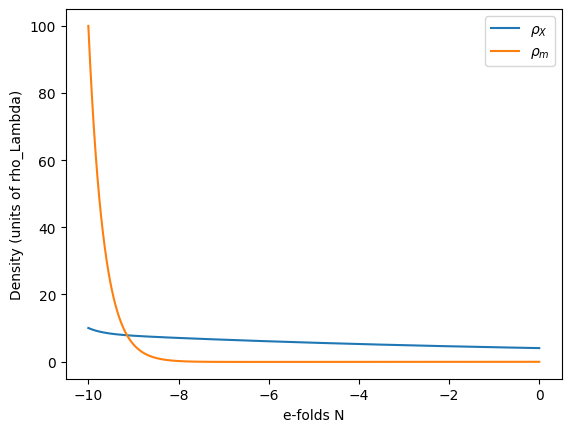

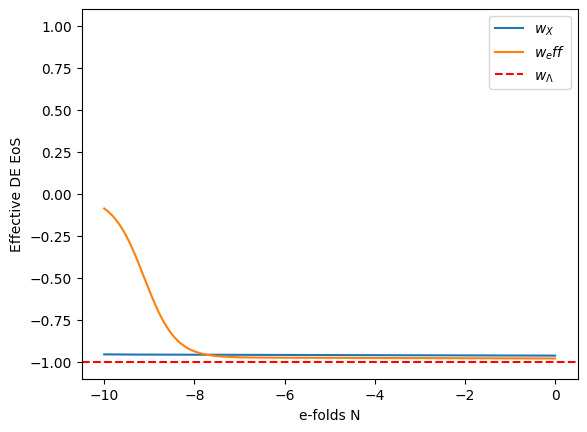

In [31]:
# Parameters to be optimised to lambda cdm data
w = -0.95
q = 0.05


def system(N, vars):
    x, y = vars

    w_x = w - (1 + w)/(x+1e-8)
    
    dx =-3*(1+w)*(x-1) + q*(x-y)
    dy =-3*y - q*(x-y)

    return [dx, dy]

N = np.linspace(-10, 0, 500) # -50 epochs is around the time of inflation but for observational data fitting i need to start today slightly back -10-0 epochs
sol = solve_ivp(system, [-10,0], [10,100] , t_eval=N)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
#large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
x = sol.y[0]
y = sol.y[1]
a = np.exp(sol.t)  # scale factor


rho_X = x * 1  # assuming rho_Lambda = 1 in code units
rho_m = y * 1
rho_tot = rho_X + rho_m + 1
w_x = w - (1 + w)/(x+1e-8)
w_eff = (w*(x-1)-1) /(x+y)

plt.figure()
plt.plot(N, x, label=r'$\rho_X$')
plt.plot(N, y, label=r'$\rho_m$')
plt.xlabel('e-folds N')
plt.ylabel('Density (units of rho_Lambda)')
#plt.xscale('log')  # log scale to show early universe
plt.legend()

plt.figure()
plt.plot(N, w_x, label=r'$w_X$')
plt.plot(N, w_eff, label=r'$w_eff$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.show()

Physical fixed points: [[1.0350877192982457, -0.017543859649122806]]
Fixed points (1.0350877192982457,-0.017543859649122806)
Eigen Values: [-1.44833518 -2.95166482]
Type=node
Stability=Attractor



/tmp/ipykernel_2860/90627675.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


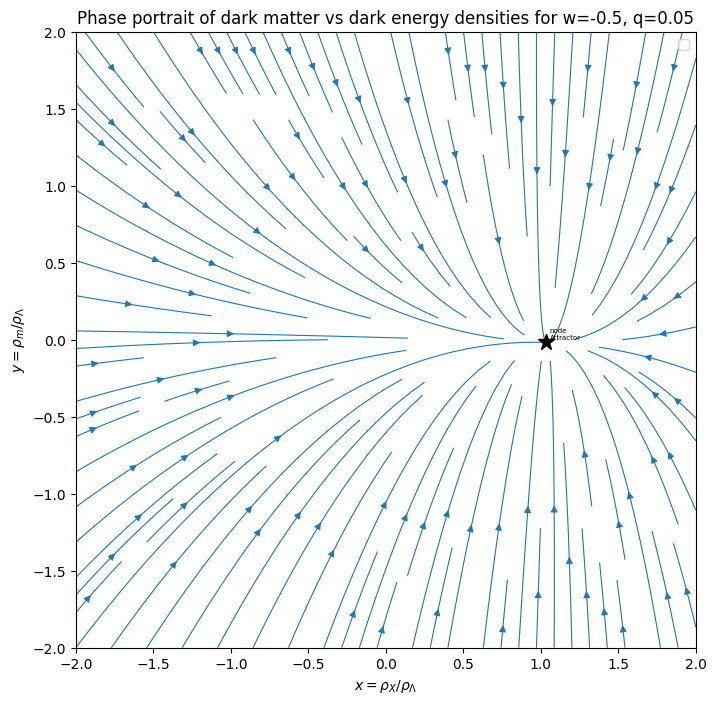

In [32]:
#plotting phase portrait at lambda slice
def phase_plot(w, q):
  def system(t, vars):
      x, y = vars

      #w_x = w - (1 + w)/(x+1e-8)
      
      dx =-3*(1+w)*(x-1) + q*(x-y)
      dy =-3*y - q*(x-y)

      return [dx, dy]

  # plot the dynamics on graph
  initialState=np.array([10, 100])

  simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
  # generate the state-space trajectory

  def stop_event(t, y):
      x, y_ = y
      return abs(x) - 1e-6  # stop near singularity

  stop_event.terminal = True

  sol = solve_ivp(system, [-10,0], initialState , t_eval=simulationTime)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
  #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
  dx = sol.y[0]
  dy = sol.y[1]
  a = np.exp(sol.t)  # scale factor

  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-2,2,10)
  x1 = np.linspace(-2,2,10)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
              dx,dy= system(0,[X0[i,j], X1[i,j]])
              dX0[i,j] = dx
              dX1[i,j] = dy

# in order to plot trajectories of solutions from fixed points, using sympy to solve the equations dx and dy =0 and 
# finding values of x and y. These can then be used in a jaconian matrix to determine eigenvalues at these fixed points which 
# determines stability.  

  x_FP, y_FP = sp.symbols('x y ', real=True)

  #w_x = w_a - (1 + w_a)/x_FP
  f =-3*(1+w)*(x_FP-1) + q*(x_FP-y_FP)
  g =-3*y_FP - q*(x_FP-y_FP)
  J_sym = sp.Matrix([f, g]).jacobian([x_FP, y_FP]) # Symbolic Jacobian for x and y 2D

  solutions = sp.solve([f, g], [x_FP, y_FP], dict=True)
  FP=[]
  for sol in solutions:
    if x_FP in sol and y_FP in sol:
      x_val = sol[x_FP]
      y_val = sol[y_FP]
      #z_val = sol[z_FP]
      #lam_val = sol[lam_FP]
      if x_val.is_real and y_val.is_real:
          x_val,y_val = float(x_val),float(y_val)
          FP.append([float(x_val),float(y_val)])
  print("Physical fixed points:", FP)

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, density=1.2, linewidth=0.8)
  #plt.plot(x_vals, y_vals, 'r', lw=2, label='Trajectory')
  #plt.plot(x_vals[0], y_vals[0], 'ro', label='Initial condition')


# classifying E vals in accordance with dynamical system analysis
  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

# plotting the fixed points by determining their eigenvalues and then classifying them using the above function
  for fp in FP:
    x_c, y_c = fp
    J_num = np.array(J_sym.subs({x_FP: x_c,y_FP: y_c}),dtype=float)
    eigvals,eigvecs = np.linalg.eig(J_num)
    stability,point_type = classify_FP(eigvals)
    print(f'Fixed points ({x_c:},{y_c})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12)
    plt.text(x_c+0.02, y_c+0.02, f"{point_type}\n{stability}", fontsize=5)

# a separatrix is plotted from a saddle point and divides areas of different dynamics along the eigenvector direction


    if stability=='saddle': 
       delta=1e-5 # small perturbations along eigenvector
       for vector,value in zip(eigvecs.T,eigvals):
          if value>0:
             for pm in [-1,1]: #either positive of negative direction
              x_start = np.array([x_c,y_c])+pm*delta*vector[:2]
              trajectory= solve_ivp(fun=system,t_span=(simulationTime[0], simulationTime[-1]),y0=x_start,t_eval=simulationTime,method='RK45',events=stop_event)
              plt.plot(trajectory.y[0],trajectory.y[1],'r--',linewidth=1)
    

  plt.xlabel(r"$x = \rho_X/ \rho_\Lambda$")
  plt.ylabel(r"$y=\rho_m/ \rho_\Lambda$")
  plt.title(rf"Phase portrait of dark matter vs dark energy densities for w={w}, q={q}")
  #plt.xlim(-1.5,1.5)
  #plt.ylim(-1.5,1.5)
  plt.legend()
  plt.show()





# try w=-0.95 and -0.5 and q=+- 0.05
phase_plot(-0.5,0.05)

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018/meta


#### Plot of x vs y vs $w_{eff}$

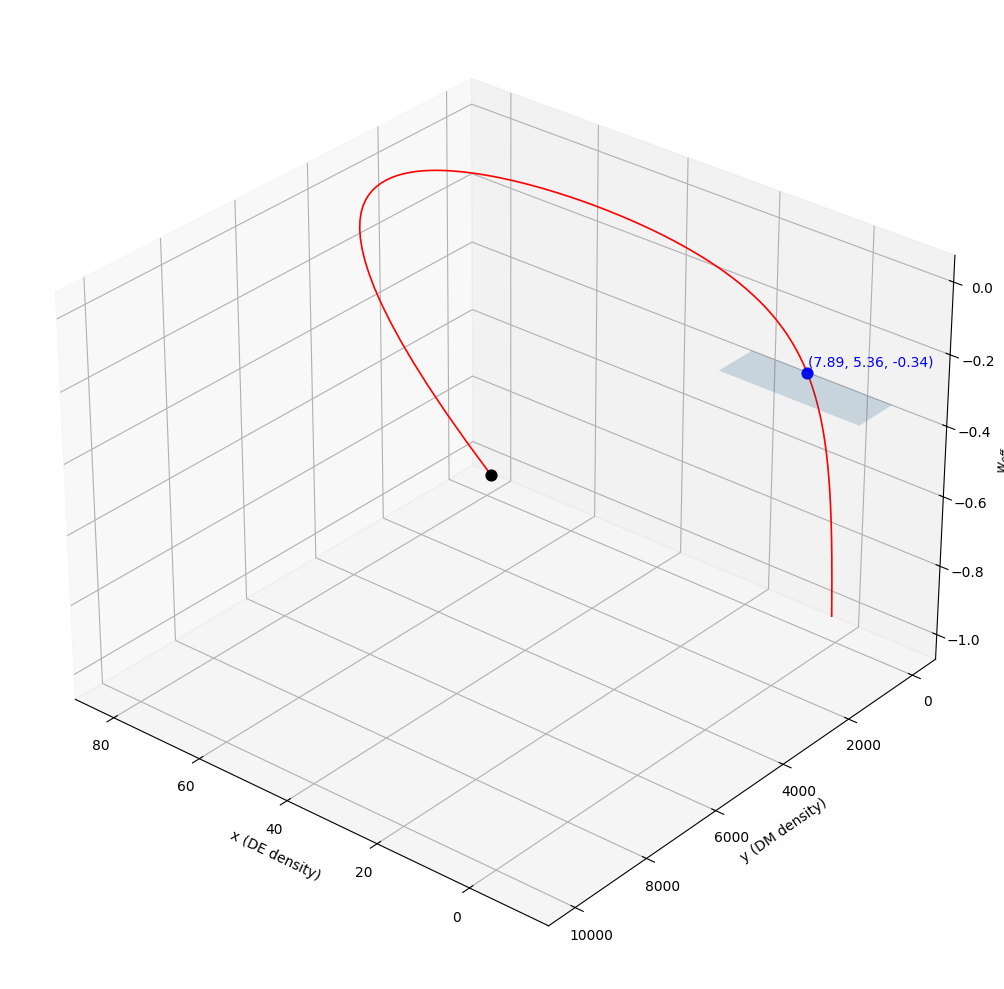

In [33]:
w,q=-0.5,-0.05



def system(t, vars):
      x, y = vars

      #w_x = w - (1 + w)/(x+1e-8)
      
      dx =-3*(1+w)*(x-1) + q*(x-y)
      dy =-3*y - q*(x-y)

      return [dx, dy]

  # plot the dynamics on graph
initialState=np.array([1, 10000]) # x~1   y=y0e^-3N~1e13

simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
  # generate the state-space trajectory

sol = solve_ivp(system, [-10,0], initialState , t_eval=simulationTime)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
  #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
x = sol.y[0]
y = sol.y[1]
weff=((w*(x-1)-1)/(x+y))

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(x, y, weff, color='r', lw=1.2)
ax.scatter3D(x[0], y[0], weff[0], color='black', s=60)

a = np.linspace(-10, 20, 100)
b = np.linspace(-10, 1000, 10000)
X, Y = np.meshgrid(a, b)
Z = np.ones(X.shape) * -1/3
ax.plot_surface(X, Y, Z, alpha=0.2)

idx = np.where(np.isclose(weff, -1/3, atol=3e-3))[0]
for i in idx:
    ax.scatter3D(x[i], y[i], weff[i], color='blue', s=60)
    ax.text(x[i]+0.02, y[i]+0.02, weff[i]+0.02, f"({x[i]:.2f}, {y[i]:.2f}, {weff[i]:.2f})", color='b')

      

ax.set_xlabel("x (DE density)")
ax.set_ylabel("y (DM density)")
ax.set_zlabel("$w_{eff}$")
ax.view_init(elev=30, azim=130)
plt.tight_layout()
plt.show()

## Using H normalised variables
#### from the affine equation of state we find $\rho_X=\rho_{dyn}+\rho_\Lambda$
#### so the Friedmann equation, $H^2 = 1/3 (\rho_m+\rho_X) =1/3 (\rho_{dyn}+\rho_m +\rho_\Lambda)$, becomes 1=x+y+z where:

#### $x=\frac{\rho_{dyn}}{3H^2}$, $y=\frac{\rho_{m}}{3H^2}$, $z=\frac{\rho_{\Lambda}}{3H^2}$ with ranges $0\leq x,y,z \leq 1 $
#### using these variables, we find that the continuity equations become a 2D system using the Friedmann constaint z=1-x-y and using the interaction term $Q=qH(\rho_X-\rho_m)$

#### $x' = 3(1+w)(x^2-x)+3xy+q(1-2y)$
#### $y' = 3(y^2-y)+3xy(1+w) -q(1-2y)$

#### $w_{eff} = \frac{P_X}{\rho_X+\rho_m}=\frac{w(\rho_X-\rho_\Lambda)-\rho_\Lambda}{\rho_X+\rho_m}$
#### $w_{eff} = \frac{wx-z}{x+y+z}= (1+w)x+y-1$

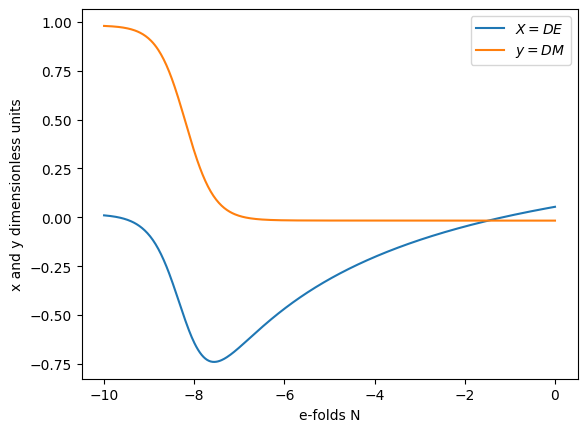

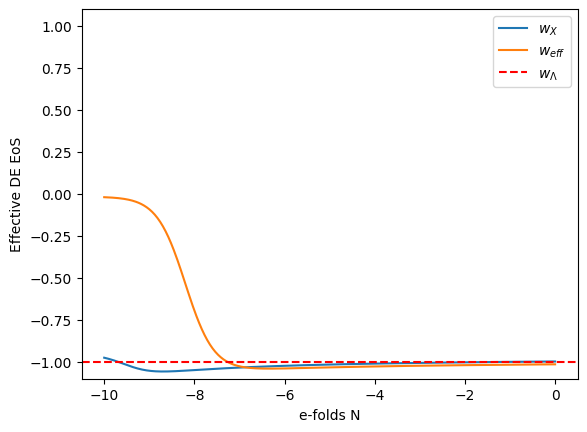

In [34]:
w,q =-0.95,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]

simulationTime=np.linspace(-10,0,500)
solution = solve_ivp(system,[-10,0],[0.01,0.98],t_eval=simulationTime)
x=solution.y[0]
y=solution.y[1]
wx= ((1+w)*x +y-1)/(1-y+1e-6)
weff=(1+w)*x +y-1



plt.figure()
plt.plot(simulationTime, x, label=r'$X=DE$')
plt.plot(simulationTime, y, label=r'$y=DM$')
plt.xlabel('e-folds N')
plt.ylabel('x and y dimensionless units')
#plt.xscale('log')  # log scale to show early universe
plt.legend()

plt.figure()
plt.plot(simulationTime, wx, label=r'$w_X$')
plt.plot(simulationTime, weff, label=r'$w_{eff}$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.show()

## 2D plot of x and y reduced by condition z=1-x-y

#### No separatrices plot:

Detected fixed points: [array([ 0.344828, -0.017241]), array([ 1.017852, -0.017852]), array([0.017236, 0.982764])]
Fixed points (0.344828,-0.017241)
Eigen Values: [-0.0991218 -2.9508746]
Type=node
Stability=Attractor

Fixed points (0.017236,0.982764)
Eigen Values: [2.8517548 2.9508774]
Type=node
Stability=Repeller



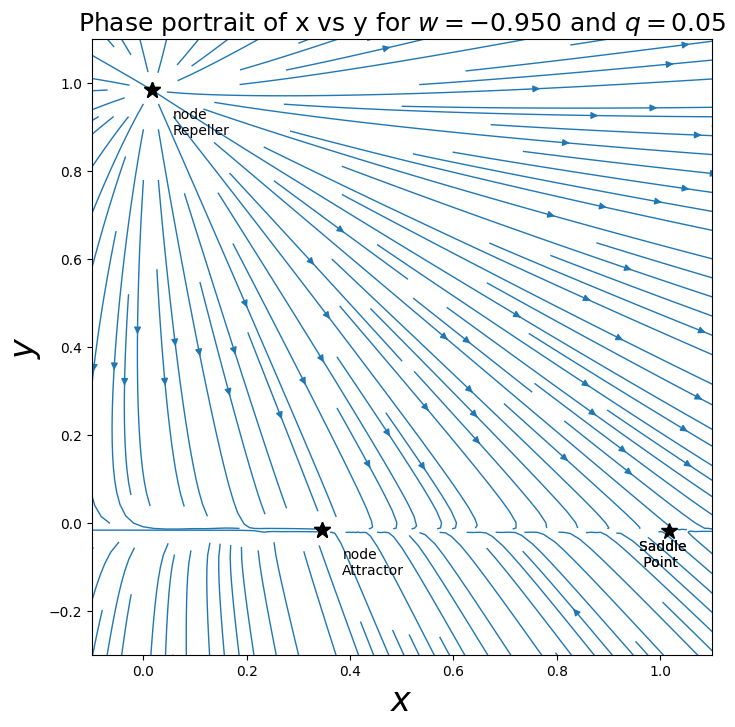

[array([ 0.344828, -0.017241]), array([ 1.017852, -0.017852]), array([0.017236, 0.982764])]


In [35]:
w,q =-0.95,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]



simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
# generate the state-space trajectory
ICs=[0.00001,0.99]

#plotting phase portrait 
def phase_plot():

  FP = find_fixed_points()
  

  
  print("Detected fixed points:",FP)


  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-1.5,1.5,500)
  x1 = np.linspace(-1.5,1.5,500)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
                if abs(X0[i,j]) >= 1.5 or abs(X1[i,j]) >= 1.5:
                  dX0[i,j] = 0
                  dX1[i,j] = 0
                else:
                  dx,dy = system(0,[X0[i,j], X1[i,j]])
                  dX0[i,j] = dx
                  dX1[i,j] = dy

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, linewidth=1, density=3.5,arrowstyle='-|>')



  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

  for fp in FP:
    x_c, y_c = fp
    plt.plot(x_c, y_c, 'k*', markersize=12)
    delta = 1e-6
    # DO NOT skip the saddle at (1,0)
    if (abs(x_c) >= 1 or abs(y_c) >= 1) and not np.allclose([x_c, y_c], [1,0], atol=1e-3):
      
      stability = "saddle"
      point_type = "Boundary"

      starts = [
                [x_c-delta,y_c],
                [x_c,y_c-delta],
                [x_c-delta,y_c-delta],
                [x_c-delta,y_c+delta]
            ]

      for start in starts:

                  start = np.clip(start,-0.999,0.999)

                  sol = solve_ivp(system,(-10, 0),start,t_eval=simulationTime)
                  #plt.plot(sol.y[0], sol.y[1], 'r--')

      continue






    
    # creating a numerical jacobian because the sympy function doesnt work when functions blow up to infinities at +-1

    eps=1e-6
    fx1 = system(0,[x_c+eps,y_c])
    fx2 = system(0,[x_c-eps,y_c])

    fy1 = system(0,[x_c,y_c+eps])
    fy2 = system(0,[x_c,y_c-eps])

    J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

    eigvals,eigvecs = np.linalg.eig(J)

    stability,point_type = classify_FP(eigvals)




    print(f'Fixed points ({x_c:},{y_c:})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12,label='Fixed Points')
    plt.text(x_c+0.04, y_c-0.1, f"{point_type}\n{stability}", fontsize=10)
    plt.text(1-0.04, 0-0.1, f"Saddle \n Point", fontsize=10)
    
    #plt.plot(1,0,'k*', markersize=12,label='Saddle Point')
    #plt.text(1-0.04, 0-0.1, f"Saddle Point", fontsize=10)

  #plt.plot(1,0,'k*', markersize=12,label='Saddle Point')
  plt.xlabel(rf"$x$",fontsize=24)
  plt.ylabel(rf"$y$",fontsize=24)
  plt.title(rf"Phase portrait of x vs y for $w={w:.3f}$ and $q={q}$",fontsize=18)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.3,1.1)
  #plot_separatrices(FP)

  #plt.legend()
  
  plt.show()
  print(FP)





def find_fixed_points():
    guesses = np.linspace(-1.2,1.2,100)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: system(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                x, y = sol.x

                if abs(x) <= 1.2 and abs(y) <= 1.2:
                    dx,dy = system(0,[x,y])

                    if abs(dx) < 1e-6 and abs(dy) < 1e-6:
                        pt = np.round([x,y],6)

                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)

    return FP

def plot_separatrices(FP):
    FP = np.array(FP)
    plt.plot([FP[1, 0], FP[0, 0]],[FP[1, 1], FP[0, 1]],color='r')

    plt.plot([FP[1, 0], FP[2, 0]], [FP[1, 1], FP[2, 1]],color='r')



phase_plot()

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018


Detected fixed points: [array([ 0.344828, -0.017241]), array([ 1.017852, -0.017852]), array([0.017236, 0.982764])]
Fixed points (0.344828,-0.017241)
Eigen Values: [-0.0991218 -2.9508746]
Type=node
Stability=Attractor

Fixed points (0.017236,0.982764)
Eigen Values: [2.8517548 2.9508774]
Type=node
Stability=Repeller



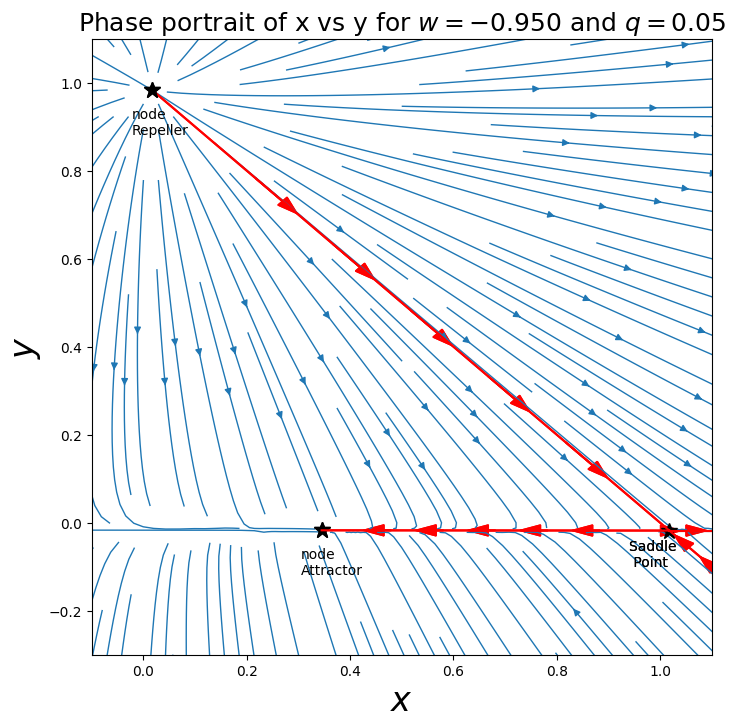

[array([ 0.344828, -0.017241]), array([ 1.017852, -0.017852]), array([0.017236, 0.982764])]


In [36]:
w,q =-0.95,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]



simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
# generate the state-space trajectory
ICs=[0.00001,0.99]

#plotting phase portrait 
def phase_plot():

  FP = find_fixed_points()
  

  
  print("Detected fixed points:",FP)


  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-1.5,1.5,500)
  x1 = np.linspace(-1.5,1.5,500)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
                if abs(X0[i,j]) >= 1.5 or abs(X1[i,j]) >= 1.5:
                  dX0[i,j] = 0
                  dX1[i,j] = 0
                else:
                  dx,dy = system(0,[X0[i,j], X1[i,j]])
                  dX0[i,j] = dx
                  dX1[i,j] = dy

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, linewidth=1, density=3.5,arrowstyle='-|>')



  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

  for fp in FP:
    x_c, y_c = fp
    plt.plot(x_c, y_c, 'k*', markersize=12)
    delta = 1e-6
    # DO NOT skip the saddle at (1,0)
    if (abs(x_c) >= 1 or abs(y_c) >= 1) and not np.allclose([x_c, y_c], [1,0], atol=1e-3):
      
      stability = "saddle"
      point_type = "Boundary"

      starts = [
                [x_c-delta,y_c],
                [x_c,y_c-delta],
                [x_c-delta,y_c-delta],
                [x_c-delta,y_c+delta]
            ]

      for start in starts:

                  start = np.clip(start,-0.999,0.999)

                  sol = solve_ivp(system,(-10, 0),start,t_eval=simulationTime)
                  #plt.plot(sol.y[0], sol.y[1], 'r--')

      continue






    
    # creating a numerical jacobian because the sympy function doesnt work when functions blow up to infinities at +-1

    eps=1e-6
    fx1 = system(0,[x_c+eps,y_c])
    fx2 = system(0,[x_c-eps,y_c])

    fy1 = system(0,[x_c,y_c+eps])
    fy2 = system(0,[x_c,y_c-eps])

    J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

    eigvals,eigvecs = np.linalg.eig(J)

    stability,point_type = classify_FP(eigvals)




    print(f'Fixed points ({x_c:},{y_c:})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plot_separatrices(FP)
    plt.plot(x_c, y_c, 'k*', markersize=12,label='Fixed Points')
    plt.text(x_c-0.04, y_c-0.1, f"{point_type}\n{stability}", fontsize=10)
    plt.text(1-0.06, 0-0.1, f"Saddle \n Point", fontsize=10)
    
    
  plt.xlabel(rf"$x$",fontsize=24)
  plt.ylabel(rf"$y$",fontsize=24)
  plt.title(rf"Phase portrait of x vs y for $w={w:.3f}$ and $q={q}$",fontsize=18)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.3,1.1)
  

  #plt.legend()
  
  plt.show()
  print(FP)





def find_fixed_points():
    guesses = np.linspace(-1.2,1.2,100)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: system(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                x, y = sol.x

                if abs(x) <= 1.2 and abs(y) <= 1.2:
                    dx,dy = system(0,[x,y])

                    if abs(dx) < 1e-6 and abs(dy) < 1e-6:
                        pt = np.round([x,y],6)

                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)

    return FP

def plot_separatrices(FP):
    FP = np.array(FP)

    def draw_line_with_arrows(p1, p2, n=5, color='r'):
        p1 = np.array(p1)
        p2 = np.array(p2)

        # Drawing line
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=1.5)

        direction = p2 - p1

        # Place arrows along the line
        for t in np.linspace(0.2, 0.8, n):
            point = (1 - t) * p1 + t * p2

            plt.arrow(point[0], point[1], 0.08 * direction[0], 0.08 * direction[1],head_width=0.025,head_length=0.04,fc='r', ec='r', length_includes_head=True)
    
    if len(FP) >= 3:
        draw_line_with_arrows(FP[1], FP[0])
        draw_line_with_arrows(FP[2], FP[1])
        draw_line_with_arrows(FP[1], [1.1,-0.017852],n=2)
        draw_line_with_arrows([1.1,-0.1], FP[1],n=2)
    



phase_plot()

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018


#### xy phase plot with separatrices w=-0.5 q=0.05 

Detected fixed points: [array([ 0.034483, -0.017241]), array([ 1.034443, -0.034443]), array([0.032223, 0.967777])]
Fixed points (0.034483,-0.017241)
Eigen Values: [-1.44833333 -2.95166217]
Type=node
Stability=Attractor

Fixed points (0.032223,0.967777)
Eigen Values: [1.503331  2.9516655]
Type=node
Stability=Repeller



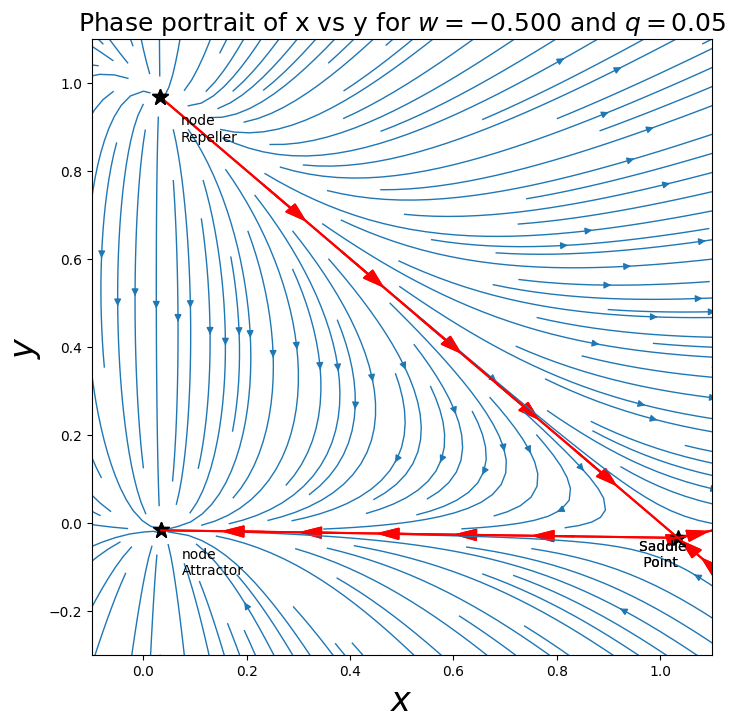

[array([ 0.034483, -0.017241]), array([ 1.034443, -0.034443]), array([0.032223, 0.967777])]


In [37]:
w,q =-0.5,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]



simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
# generate the state-space trajectory
ICs=[0.00001,0.99]

#plotting phase portrait 
def phase_plot():

  FP = find_fixed_points()
  

  
  print("Detected fixed points:",FP)


  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-1.5,1.5,500)
  x1 = np.linspace(-1.5,1.5,500)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
                if abs(X0[i,j]) >= 1.5 or abs(X1[i,j]) >= 1.5:
                  dX0[i,j] = 0
                  dX1[i,j] = 0
                else:
                  dx,dy = system(0,[X0[i,j], X1[i,j]])
                  dX0[i,j] = dx
                  dX1[i,j] = dy

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, linewidth=1, density=3.5,arrowstyle='-|>')



  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

  for fp in FP:
    x_c, y_c = fp
    plt.plot(x_c, y_c, 'k*', markersize=12)
    delta = 1e-6
    # DO NOT skip the saddle at (1,0)
    if (abs(x_c) >= 1 or abs(y_c) >= 1) and not np.allclose([x_c, y_c], [1,0], atol=1e-3):
      
      stability = "saddle"
      point_type = "Boundary"

      starts = [
                [x_c-delta,y_c],
                [x_c,y_c-delta],
                [x_c-delta,y_c-delta],
                [x_c-delta,y_c+delta]
            ]

      for start in starts:

                  start = np.clip(start,-0.999,0.999)

                  sol = solve_ivp(system,(-10, 0),start,t_eval=simulationTime)
                  #plt.plot(sol.y[0], sol.y[1], 'r--')

      continue






    
    # creating a numerical jacobian because the sympy function doesnt work when functions blow up to infinities at +-1

    eps=1e-6
    fx1 = system(0,[x_c+eps,y_c])
    fx2 = system(0,[x_c-eps,y_c])

    fy1 = system(0,[x_c,y_c+eps])
    fy2 = system(0,[x_c,y_c-eps])

    J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

    eigvals,eigvecs = np.linalg.eig(J)

    stability,point_type = classify_FP(eigvals)




    print(f'Fixed points ({x_c:},{y_c:})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plot_separatrices(FP)
    plt.plot(x_c, y_c, 'k*', markersize=12,label='Fixed Points')
    plt.text(x_c+0.04, y_c-0.1, f"{point_type}\n{stability}", fontsize=10)
    plt.text(1-0.04, 0-0.1, f"Saddle \n Point", fontsize=10)
    
    
  plt.xlabel(rf"$x$",fontsize=24)
  plt.ylabel(rf"$y$",fontsize=24)
  plt.title(rf"Phase portrait of x vs y for $w={w:.3f}$ and $q={q}$",fontsize=18)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.3,1.1)
  

  #plt.legend()
  
  plt.show()
  print(FP)





def find_fixed_points():
    guesses = np.linspace(-1.2,1.2,100)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: system(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                x, y = sol.x

                if abs(x) <= 1.2 and abs(y) <= 1.2:
                    dx,dy = system(0,[x,y])

                    if abs(dx) < 1e-6 and abs(dy) < 1e-6:
                        pt = np.round([x,y],6)

                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)

    return FP

def plot_separatrices(FP):
    FP = np.array(FP)

    def draw_line_with_arrows(p1, p2, n=5, color='r'):
        p1 = np.array(p1)
        p2 = np.array(p2)

        # Drawing line
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=1.5)

        direction = p2 - p1

        # Place arrows along the line
        for t in np.linspace(0.2, 0.8, n):
            point = (1 - t) * p1 + t * p2

            plt.arrow(point[0], point[1], 0.08 * direction[0], 0.08 * direction[1],head_width=0.025,head_length=0.04,fc='r', ec='r', length_includes_head=True)
    
    if len(FP) >= 3:
        draw_line_with_arrows(FP[1], FP[0])
        draw_line_with_arrows(FP[2], FP[1])
        draw_line_with_arrows(FP[1], [1.1,-0.017852],n=2)
        draw_line_with_arrows([1.1,-0.1], FP[1],n=2)



phase_plot()

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018


#### xy phase plot with separatrices w=-0.95 q=-0.05

Detected fixed points: [array([-0.322581,  0.016129]), array([0.982764, 0.017236]), array([-0.017852,  1.017852])]
Fixed points (-0.322581,0.016129)
Eigen Values: [-0.19912328 -3.05087717]
Type=node
Stability=Attractor

Fixed points (0.982764,0.017236)
Eigen Values: [ 0.1991226 -2.8517548]
Type=node
Stability=saddle



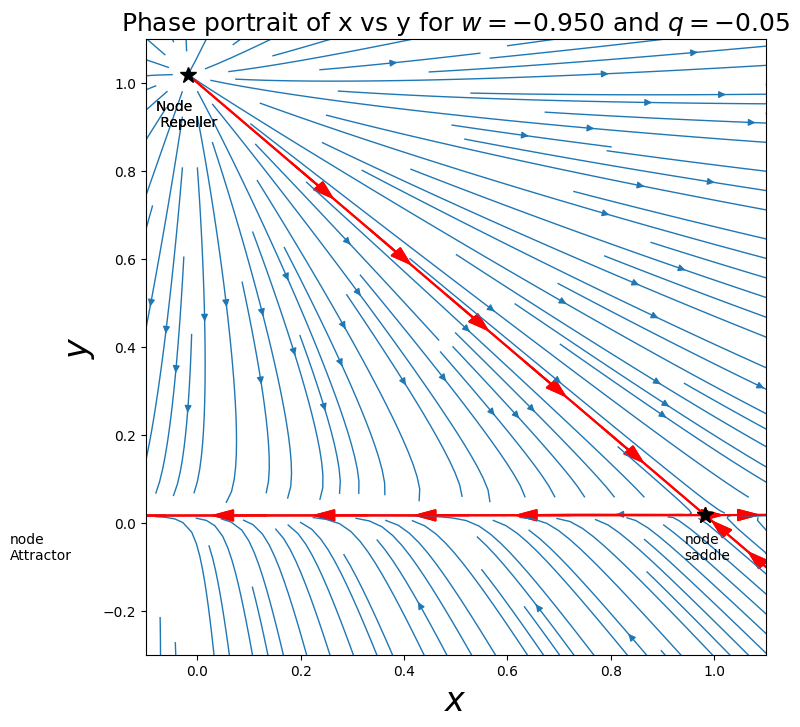

[array([-0.322581,  0.016129]), array([0.982764, 0.017236]), array([-0.017852,  1.017852])]


In [38]:
w,q =-0.95,-0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]



simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
# generate the state-space trajectory
ICs=[0.00001,0.99]

#plotting phase portrait 
def phase_plot():

  FP = find_fixed_points()
  

  
  print("Detected fixed points:",FP)


  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-1.5,1.5,500)
  x1 = np.linspace(-1.5,1.5,500)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
                if abs(X0[i,j]) >= 1.5 or abs(X1[i,j]) >= 1.5:
                  dX0[i,j] = 0
                  dX1[i,j] = 0
                else:
                  dx,dy = system(0,[X0[i,j], X1[i,j]])
                  dX0[i,j] = dx
                  dX1[i,j] = dy

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, linewidth=1, density=3.5,arrowstyle='-|>')



  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

  for fp in FP:
    x_c, y_c = fp
    plt.plot(x_c, y_c, 'k*', markersize=12)
    delta = 1e-6
    # DO NOT skip the saddle at (1,0)
    if (abs(x_c) >= 1 or abs(y_c) >= 1) and not np.allclose([x_c, y_c], [1,0], atol=1e-3):
      
      stability = "saddle"
      point_type = "Boundary"

      starts = [
                [x_c-delta,y_c],
                [x_c,y_c-delta],
                [x_c-delta,y_c-delta],
                [x_c-delta,y_c+delta]
            ]

      for start in starts:

                  start = np.clip(start,-0.999,0.999)

                  sol = solve_ivp(system,(-10, 0),start,t_eval=simulationTime)
                  #plt.plot(sol.y[0], sol.y[1], 'r--')

      continue






    
    # creating a numerical jacobian because the sympy function doesnt work when functions blow up to infinities at +-1

    eps=1e-6
    fx1 = system(0,[x_c+eps,y_c])
    fx2 = system(0,[x_c-eps,y_c])

    fy1 = system(0,[x_c,y_c+eps])
    fy2 = system(0,[x_c,y_c-eps])

    J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

    eigvals,eigvecs = np.linalg.eig(J)

    stability,point_type = classify_FP(eigvals)




    print(f'Fixed points ({x_c:},{y_c:})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plot_separatrices(FP)
    plt.plot(x_c, y_c, 'k*', markersize=12,label='Fixed Points')
    plt.text(x_c-0.04, y_c-0.1, f"{point_type}\n{stability}", fontsize=10)
    plt.text(0-0.08, 1-0.1, f"Node \n Repeller", fontsize=10)
    
    
  plt.xlabel(rf"$x$",fontsize=24)
  plt.ylabel(rf"$y$",fontsize=24)
  plt.title(rf"Phase portrait of x vs y for $w={w:.3f}$ and $q={q}$",fontsize=18)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.3,1.1)
  

  #plt.legend()
  
  plt.show()
  print(FP)





def find_fixed_points():
    guesses = np.linspace(-1.2,1.2,100)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: system(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                x, y = sol.x

                if abs(x) <= 1.2 and abs(y) <= 1.2:
                    dx,dy = system(0,[x,y])

                    if abs(dx) < 1e-6 and abs(dy) < 1e-6:
                        pt = np.round([x,y],6)

                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)

    return FP

def plot_separatrices(FP):
    FP = np.array(FP)

    def draw_line_with_arrows(p1, p2, n=5, color='r'):
        p1 = np.array(p1)
        p2 = np.array(p2)

        # Drawing line
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=1.5)

        direction = p2 - p1

        # Place arrows along the line
        for t in np.linspace(0.2, 0.8, n):
            point = (1 - t) * p1 + t * p2

            plt.arrow(point[0], point[1], 0.08 * direction[0], 0.08 * direction[1],head_width=0.025,head_length=0.04,fc='r', ec='r', length_includes_head=True)
    
    if len(FP) >= 3:
        draw_line_with_arrows(FP[1], FP[0])
        draw_line_with_arrows(FP[2], FP[1])
        draw_line_with_arrows(FP[1], [1.1,0.017852],n=2)
        draw_line_with_arrows([1.1,-0.1], FP[1],n=2)



phase_plot()

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018


#### xy phase plot with separatrices w=-0.5 q=-0.05

Detected fixed points: [array([-0.032258,  0.016129]), array([0.967777, 0.032223]), array([-0.034443,  1.034443])]
Fixed points (-0.032258,0.016129)
Eigen Values: [-1.54833508 -3.05166492]
Type=node
Stability=Attractor

Fixed points (0.967777,0.032223)
Eigen Values: [ 1.5483345 -1.503331 ]
Type=node
Stability=saddle



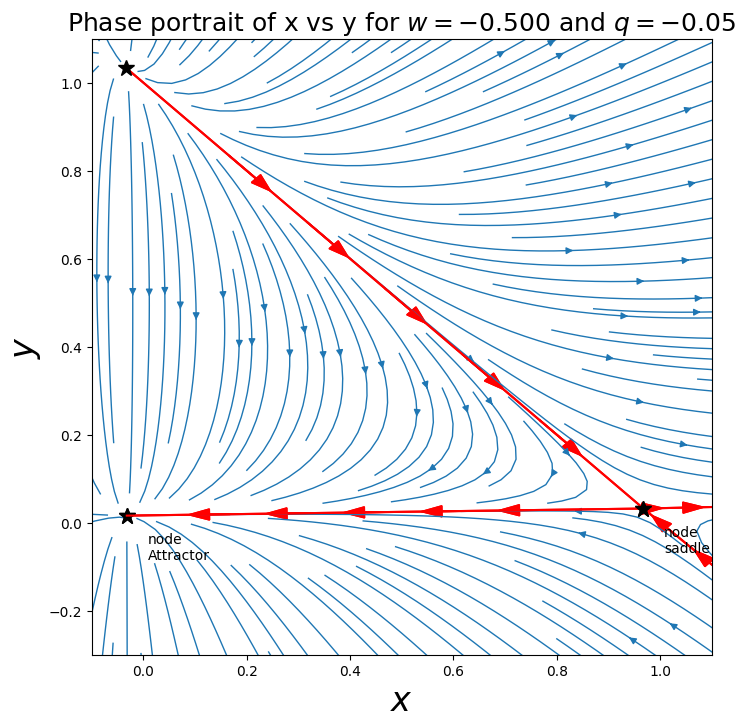

[array([-0.032258,  0.016129]), array([0.967777, 0.032223]), array([-0.034443,  1.034443])]


In [39]:
w,q =-0.5,-0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]



simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
# generate the state-space trajectory
ICs=[0.00001,0.99]

#plotting phase portrait 
def phase_plot():

  FP = find_fixed_points()
  

  
  print("Detected fixed points:",FP)


  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-1.5,1.5,500)
  x1 = np.linspace(-1.5,1.5,500)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
                if abs(X0[i,j]) >= 1.5 or abs(X1[i,j]) >= 1.5:
                  dX0[i,j] = 0
                  dX1[i,j] = 0
                else:
                  dx,dy = system(0,[X0[i,j], X1[i,j]])
                  dX0[i,j] = dx
                  dX1[i,j] = dy

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, linewidth=1, density=3.5,arrowstyle='-|>')



  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

  for fp in FP:
    x_c, y_c = fp
    plt.plot(x_c, y_c, 'k*', markersize=12)
    delta = 1e-6
    # DO NOT skip the saddle at (1,0)
    if (abs(x_c) >= 1 or abs(y_c) >= 1) and not np.allclose([x_c, y_c], [1,0], atol=1e-3):
      
      stability = "saddle"
      point_type = "Boundary"

      starts = [
                [x_c-delta,y_c],
                [x_c,y_c-delta],
                [x_c-delta,y_c-delta],
                [x_c-delta,y_c+delta]
            ]

      for start in starts:

                  start = np.clip(start,-0.999,0.999)

                  sol = solve_ivp(system,(-10, 0),start,t_eval=simulationTime)
                  #plt.plot(sol.y[0], sol.y[1], 'r--')

      continue






    
    # creating a numerical jacobian because the sympy function doesnt work when functions blow up to infinities at +-1

    eps=1e-6
    fx1 = system(0,[x_c+eps,y_c])
    fx2 = system(0,[x_c-eps,y_c])

    fy1 = system(0,[x_c,y_c+eps])
    fy2 = system(0,[x_c,y_c-eps])

    J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

    eigvals,eigvecs = np.linalg.eig(J)

    stability,point_type = classify_FP(eigvals)




    print(f'Fixed points ({x_c:},{y_c:})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plot_separatrices(FP)
    plt.plot(x_c, y_c, 'k*', markersize=12,label='Fixed Points')
    plt.text(x_c+0.04, y_c-0.1, f"{point_type}\n{stability}", fontsize=10)
    #plt.text(1-0.04, 0-0.1, f"Saddle \n Point", fontsize=10)
    
    
  plt.xlabel(rf"$x$",fontsize=24)
  plt.ylabel(rf"$y$",fontsize=24)
  plt.title(rf"Phase portrait of x vs y for $w={w:.3f}$ and $q={q}$",fontsize=18)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.3,1.1)
  

  #plt.legend()
  
  plt.show()
  print(FP)





def find_fixed_points():
    guesses = np.linspace(-1.2,1.2,100)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: system(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                x, y = sol.x

                if abs(x) <= 1.2 and abs(y) <= 1.2:
                    dx,dy = system(0,[x,y])

                    if abs(dx) < 1e-6 and abs(dy) < 1e-6:
                        pt = np.round([x,y],6)

                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)

    return FP

def plot_separatrices(FP):
    FP = np.array(FP)

    def draw_line_with_arrows(p1, p2, n=5, color='r'):
        p1 = np.array(p1)
        p2 = np.array(p2)

        # Drawing line
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=1.5)

        direction = p2 - p1

        # Place arrows along the line
        for t in np.linspace(0.2, 0.8, n):
            point = (1 - t) * p1 + t * p2

            plt.arrow(point[0], point[1], 0.08 * direction[0], 0.08 * direction[1],head_width=0.025,head_length=0.04,fc='r', ec='r', length_includes_head=True)
    
    if len(FP) >= 3:
        draw_line_with_arrows(FP[1], FP[0])
        draw_line_with_arrows(FP[2], FP[1])
        draw_line_with_arrows(FP[1], [1.1,2*0.017852],n=2)
        draw_line_with_arrows([1.105,-0.1], FP[1],n=2)



phase_plot()

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018


### Includes radiation factor so that 1=x+y+z+R

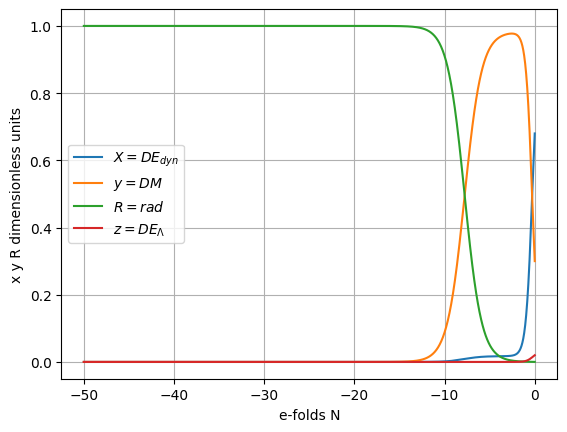

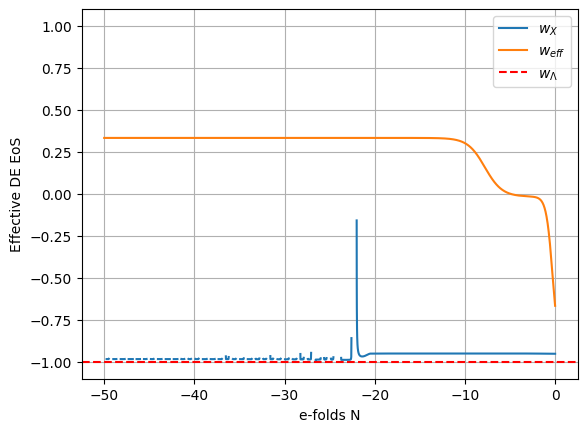

In [40]:
w,q =-0.95,0.05


def system(t,vars):
    x,y,R=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y-R)+4*x*R #dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y-R)+4*y*R #dynamic DM
    dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2
    #   to plot standard Lambda CDM, set q=0, w=-1 and get rid of xR,yR and R^2 terms. 
    return [dx,dy,dR]

simulationTime=np.linspace(0,-50,5000)
solution = solve_ivp(system,[0,-50],[0.68,0.3,9e-5],method='RK45',t_eval=simulationTime,rtol=1e-6,atol=1e-6)# using standard modern observational fractions
x=solution.y[0]
y=solution.y[1]
R=solution.y[2]

z=1-x-y-R
#wx = ((w*x - z) / (x + z ))
wx = np.full_like(x, np.nan)

mask = (x+z)  > 1e-10   # only compute where valid

wx[mask] = (w*x[mask] - z[mask]) / (x+z)[mask]

#wx= ((1+w)*x-1+y+R)/(1-y-R)
weff=(1+w)*x+4/3 *R +y-1


plt.figure()
plt.plot(simulationTime, x, label=r'$X=DE_{dyn}$')
plt.plot(simulationTime, y, label=r'$y=DM$')
plt.plot(simulationTime, R, label=r'$R=rad$')
plt.plot(simulationTime, z, label=r'$z=DE_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('x y R dimensionless units')
#plt.xscale('log')  # log scale to show early universe
plt.legend()
plt.grid()


plt.figure()
plt.plot(simulationTime, wx, label=r'$w_X$')
plt.plot(simulationTime, weff, label=r'$w_{eff}$')
plt.axhline(y=-1, color='r', linestyle='--', label=r'$w_\Lambda$')
plt.xlabel('e-folds N')
plt.ylabel('Effective DE EoS')
plt.ylim(-1.1,1.1)
#plt.xscale('log')
plt.legend()
plt.grid()

plt.show()

Graph A shows the combined evolution of the radiation, matter and dynamical dark energy densities, normalised with respect to the Hubble parameter. It shows large radiation domination era from -50 to -10 epochs in accordance with Lambda CDM observations. Then a matter domination era from -10 to -0.7 epochs (somewhat different due to interaction term keeping matter relevant for longer) and then dark energy domination from then on up until present day.

Graph B presents the evolving effective and dark energy equations of state. weff is the effective equation of state and takes the value of 1/3 for the radiation dominated era as matter and DE are minimal, but then dips during the matter domination era but not to exactly 0 as there are DE adn DM interactions forcing it lower, and then finally it tends towards ~-1 for late times during DE domination. In here, the $w_X$ at early and middle times looks to oscillate, this is due to the nature of the coupling term. It is resorative and so naturally has sign changes that becomes increasingly more frequent as the matter component becomes more relevant. Up until around N=-20 where matter is not dominating but is increasingly relevant, but late enough in the evolution that the affine parameter term $w$ comes to dominate the equation $w_X=w-(1+w)\frac{\rho_\Lambda}{\rho_X}$. This is of little consequence to the overall dynamics as DE at this point is dynamically irrelevant. 

## Plot of xyz 
#### with R=1-x-y-z to compare evolution of matter to both affine dark energy componants

FP: (0.000, 0.000, 0.000)
Eigenvalues: [3.90087692 1.04912308 4.        ]
Stability: Repeller 

FP: (0.017, 0.983, 0.000)
Eigenvalues: [ 2.85175385 -1.04912308  2.95087692]
Stability: Saddle 



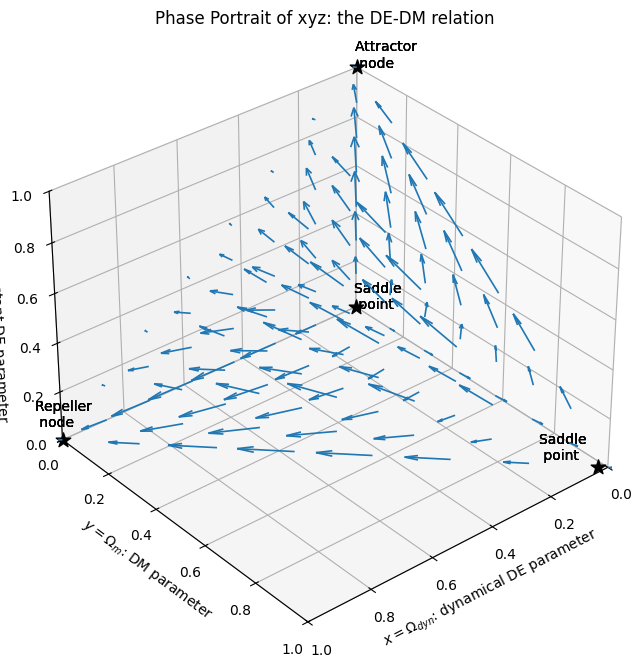

[[0.         0.         0.        ]
 [0.01723617 0.98276383 0.        ]
 [0.         0.         1.        ]
 [1.         0.         0.        ]]


In [43]:
w, q = -0.95, 0.05

def system(t, vars):
    x, y, z = vars
    R=1-x-y-z
    dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
    dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
    dz= 3*z*x*(1+w) +3*y*z+ 4*z*R
    #dR = -4*R + 3*(1+w)*x*R + 3*y*R + 4*R**2

    return [dx, dy, dz]

simulationTime = np.linspace(0, -50, 2000)
initialState =[0,0.3,0.7]

def phase_plot_3D():
    sol = solve_ivp(system, [0,-50], initialState , t_eval=simulationTime,rtol=1e-6, atol=1e-6)#  for initial conditions matter (y) now ~0.4 and so DM (x) ~0.6. For early time, large x for DE domination and 
     #large y for matter epochs. Using present values, y(-50)=0.4e^(-3*-50) and x(-50)=0.6e^(-3(1+w))
    x = sol.y[0]
    y = sol.y[1]
    z=sol.y[2]

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    grid_points = 8   # LOWER = cleaner (Mathematica style)

    xg = np.linspace(0, 1, grid_points)
    yg = np.linspace(0, 1, grid_points)
    zg = np.linspace(0, 1, grid_points)

    X, Y, Z = np.meshgrid(xg, yg, zg)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    W = np.zeros_like(Z)

    for i in range(grid_points):
        for j in range(grid_points):
            for k in range(grid_points):
                xx, yy, zz = X[i, j, k], Y[i, j, k], Z[i, j, k]

                # Only physical region
                if xx + yy + zz > 1:
                    U[i,j,k] = np.nan
                    V[i,j,k] = np.nan
                    W[i,j,k] = np.nan
                    continue

                dx, dy, dz = system(0, [xx, yy, zz])

                U[i,j,k] = dx
                V[i,j,k] = dy
                W[i,j,k] = dz

    ax.quiver(X, Y, Z, U, V, W,length=0.15,linewidth=1.2,alpha=1)


    x_FP, y_FP, z_FP = sp.symbols('x y z', real=True)

    f = 3*(1+w)*(x_FP**2 - x_FP) + 3*x_FP*y_FP + q*(1 - 2*y_FP - (1-x_FP-y_FP-z_FP)) + 4*x_FP*(1-x_FP-y_FP-z_FP)
    g = 3*(y_FP**2 - y_FP) + 3*x_FP*y_FP*(1+w) - q*(1 - 2*y_FP - (1-x_FP-y_FP-z_FP)) + 4*y_FP*(1-x_FP-y_FP-z_FP)
    h = 3*z_FP*x_FP*(1+w) +3*y_FP*z_FP+4*z_FP*(1-x_FP-y_FP-z_FP)

    J = sp.Matrix([f, g, h]).jacobian([x_FP, y_FP, z_FP])

    solutions = sp.solve([f, g, h], [x_FP, y_FP, z_FP], dict=True)

    FP = []

    def classify(eigvals):
        real = np.real(eigvals)
        if np.all(real < 0):
            return "Attractor"
        elif np.all(real > 0):
            return "Repeller"
        else:
            return "Saddle"
   
    eigvec_list=[]
    for sol in solutions:
        try:
            x_val = float(sol[x_FP])
            y_val = float(sol[y_FP])
            z_val = float(sol[z_FP])

            if x_val < 0 or y_val < 0 or z_val < 0:
                continue
            if x_val + y_val + z_val > 1 + 1e-6:
                continue
            
            J_num = np.array(J.subs(sol), dtype=float)
            eigvals,eigvecs = np.linalg.eig(J_num)
            eigvec_list.append(eigvecs)
            

            print(f"FP: ({x_val:.3f}, {y_val:.3f}, {z_val:.3f})")
            print("Eigenvalues:", eigvals)
            print("Stability:", classify(eigvals) ,'\n' )

            FP.append([x_val, y_val, z_val])

        except:
            pass

    Extra_FP = [[0,0,1],[1,0,0]]

    FP=FP+Extra_FP

    for fp in FP:

        x_c, y_c, z_c = fp
        delta=0.05
        #J_num = np.array(J.subs({x_FP: x_c, y_FP: y_c, z_FP: z_c}), dtype=float)
        #eigvals, eigvecs = np.linalg.eig(J_num)

        #stability = classify(eigvals)

        #print(f"FP {fp}, stability: {stability}, eig={eigvals}")

        ax.scatter(x_c, y_c, z_c, color='k', s=120, marker='*')
        ax.text(0+3*delta,1-2*delta,0+delta,'Saddle \n point')
        ax.text(0+delta,0+delta,0+delta,'Saddle \n point')
        ax.text(1+delta,0-delta,0+delta,'Repeller \n node')
        ax.text(0+delta,0+delta,1+delta,'Attractor \n node')

    
    FP=np.array(FP)


        

    ax.set_xlabel(r'$x=\Omega_{dyn}$: dynamical DE parameter')
    ax.set_ylabel(r'$y=\Omega_{m}$: DM parameter')
    ax.set_zlabel(r'$z=\Omega_{\Lambda}$: constant DE parameter')
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_zlim([0,1])
    ax.view_init(elev=33, azim=50)
    ax.set_title(r'Phase Portrait of xyz: the DE-DM relation')
    plt.show()
    print(FP)



def integrate_separatrix(FP, eigvec, direction, T=50, eps=1e-5):
   
    #direction = +1 for unstable (forward time)
    #direction = -1 for stable (backward time)
    
    FP = np.array(FP, dtype=float)
    v = np.array(eigvec, dtype=float)
    v = v / np.linalg.norm(v)

    # small perturbation
    P0 = FP + eps * v
    P0 = np.maximum(P0, 1e-12)  # avoid negatives
    P0 = P0 / np.sum(P0)

    # integrate
    t_span = [0, direction*T]
    sol = solve_ivp(system, t_span, P0, max_step=0.05, rtol=1e-8, atol=1e-8)

    return sol.y.T


phase_plot_3D()



FP: (0.000, 0.000, 0.000)
Eigenvalues: [3.90087692 1.04912308 4.        ] 

FP: (0.017, 0.983, 0.000)
Eigenvalues: [ 2.85175385 -1.04912308  2.95087692] 

FP: (1.018, -0.018, 0.000)
Eigenvalues: [-3.90087692 -2.85175385  0.09912308] 

FP: (0.338, 0.000, 0.675)
Eigenvalues: [-0.09999971 -4.04837345 -2.90162684] 

FP: (1.013, 0.000, 0.000)
Eigenvalues: [-3.94838848 -2.80161152  0.1       ] 

FP: (0.000, -0.017, 1.004)
Eigenvalues: [-0.14993327 -3.94821411 -2.95185262] 

FP: (0.000, 1.050, 0.000)
Eigenvalues: [ 2.90178046 -1.10178046  2.95      ] 

FP: (1.000, 0.000, 0.000)
Eigenvalues: [-3.85 -2.75  0.15] 

FP: (0.000, 1.000, 0.000)
Eigenvalues: [ 2.95 -1.    3.  ] 

FP: (0.000, 0.000, 1.000)
Eigenvalues: [-0.15 -4.   -2.9 ] 



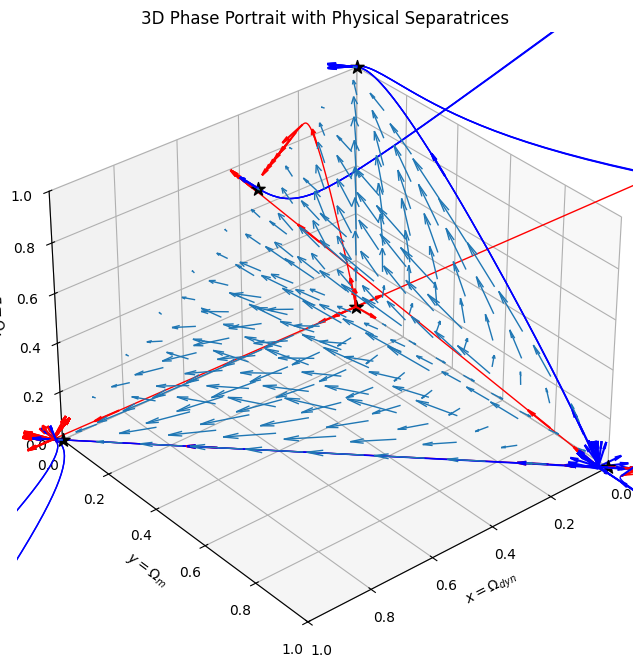

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp

w, q = -0.95, 0.05


def system(t, vars):
    x, y, z = vars
    R = 1 - x - y - z

    dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
    dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
    dz = 3*z*x*(1+w) + 3*y*z + 4*z*R

    return [dx, dy, dz]


def integrate_separatrix(fp, v, direction, T=10, eps=1e-5):

    fp = np.array(fp, dtype=float)
    v = np.array(v, dtype=float)

    # project onto simplex tangent space
    v = v - np.mean(v)

    norm = np.linalg.norm(v) #normalise arrow lengths
    if norm == 0:
        return None
    v = v / norm

    P0 = fp + eps * v
    P0 = np.maximum(P0, 1e-12)

    t_span = [0, direction*T]

    sol = solve_ivp(
        system,
        t_span,
        P0,
        max_step=0.05,
        rtol=1e-8,
        atol=1e-8
    )

    return sol.y.T

def draw_lines_with_arrows(ax, traj, direction_sign, color='k', n_arrows=10):
    if len(traj) < 2:
        return
    
    # plot the curve
    ax.plot(traj[:,0], traj[:,1], traj[:,2], color=color, lw=1)

    # pick arrow positions along trajectory
    idx = np.linspace(1, len(traj)-2, n_arrows).astype(int)

    for i in idx:

        p = traj[i]

        # local tangent direction
        dp = traj[i+1] - traj[i-1]

        norm = np.linalg.norm(dp)
        if norm == 0:
            continue
        dp = dp / norm

        # flip for stability direction
        dp = direction_sign * dp

        ax.quiver(
            p[0], p[1], p[2],
            dp[0], dp[1], dp[2],
            length=0.08,
            normalize=True,
            color=color
        )



def phase_plot_3D():

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    xs = np.linspace(0, 1, 10)
    ys = np.linspace(0, 1, 10)
    zs = np.linspace(0, 1, 10)

    X, Y, Z = np.meshgrid(xs, ys, zs)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    W = np.zeros_like(Z)

    for i in range(10):
        for j in range(10):
            for k in range(10):

                xx, yy, zz = X[i,j,k], Y[i,j,k], Z[i,j,k]

                if xx + yy + zz > 1:
                    U[i,j,k] = np.nan
                    V[i,j,k] = np.nan
                    W[i,j,k] = np.nan
                    continue

                dx, dy, dz = system(0, [xx, yy, zz])

                U[i,j,k] = dx
                V[i,j,k] = dy
                W[i,j,k] = dz

    ax.quiver(X, Y, Z, U, V, W, length=0.15, linewidth=1.0)

    x, y, z = sp.symbols('x y z', real=True)
    R = 1 - x - y - z

    f = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
    g = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
    h = 3*z*x*(1+w) + 3*y*z + 4*z*R

    FP = []
    eigvec_list = []

    def add_fp(xv, yv, zv):

        pt = np.array([xv, yv, zv], dtype=float)

        if not any(np.allclose(pt, p, atol=1e-5) for p in FP):

            FP.append(pt)

            # numerical Jacobian
            eps = 1e-6
            J = np.zeros((3,3))

            base = np.array(system(0, pt))

            for i in range(3):
                shift = pt.copy()
                shift[i] += eps
                f1 = np.array(system(0, shift))

                shift[i] -= 2*eps
                f2 = np.array(system(0, shift))

                J[:, i] = (f1 - f2)/(2*eps)

            eigvals, eigvecs = np.linalg.eig(J)
            eigvec_list.append((eigvals, eigvecs))

            print(f"FP: ({xv:.3f}, {yv:.3f}, {zv:.3f})")
            print("Eigenvalues:", eigvals, "\n")

    solutions = sp.solve([f, g, h], [x, y, z], dict=True)

    for sol in solutions:
        try:
            xv = float(sol[x])
            yv = float(sol[y])
            zv = float(sol[z])

            if xv >= 0 and yv >= 0 and zv >= 0 and xv+yv+zv <= 1+1e-6:
                add_fp(xv, yv, zv)

        except:
            pass

    #solving FP at boundaries
    # z = 0
    for sol in sp.solve([f.subs(z,0), g.subs(z,0)], [x,y], dict=True):
        try:
            add_fp(float(sol[x]), float(sol[y]), 0.0)
        except:
            pass

    # y = 0
    for sol in sp.solve([f.subs(y,0), h.subs(y,0)], [x,z], dict=True):
        try:
            add_fp(float(sol[x]), 0.0, float(sol[z]))
        except:
            pass

    # x = 0
    for sol in sp.solve([g.subs(x,0), h.subs(x,0)], [y,z], dict=True):
        try:
            add_fp(0.0, float(sol[y]), float(sol[z]))
        except:
            pass

    # vertices
    add_fp(0,0,0)
    add_fp(1,0,0)
    add_fp(0,1,0)
    add_fp(0,0,1)

    FP = np.array(FP)

    FP_manual = [[1,0,0],[0,1,0],[0,0,1],[0,0,0],[0.338,0,0.675]]
    for fp in FP_manual:
        ax.scatter(fp[0], fp[1], fp[2], color='k', s=100, marker='*')

    # separatrices
    for i, fp in enumerate(FP):

        eigvals, eigvecs = eigvec_list[i]

        for j in range(len(eigvals)):

            lam = eigvals[j]
            v = eigvecs[:, j]

            if np.real(lam) > 0:
                sol = integrate_separatrix(fp, v, +1)
                if sol is not None:
                    draw_lines_with_arrows(ax, sol, direction_sign=+1, color='red')

            elif np.real(lam) < 0:
                sol = integrate_separatrix(fp, v, -1)
                if sol is not None:
                    draw_lines_with_arrows(ax, sol, direction_sign=-1, color='blue')


    ax.set_xlabel(r'$x=\Omega_{dyn}$')
    ax.set_ylabel(r'$y=\Omega_{m}$')
    ax.set_zlabel(r'$z=\Omega_{\Lambda}$')

    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_zlim([0,1])

    ax.view_init(elev=33, azim=50)
    ax.set_title('3D Phase Portrait with Physical Separatrices')

    plt.show()


phase_plot_3D()

FP: (0.000, 0.000, 0.000)
Eigenvalues: [3.90087692 1.04912308 4.        ]
type=Unstable Node
type=Repeller

FP: (0.017, 0.983, 0.000)
Eigenvalues: [ 2.85175385 -1.04912308  2.95087692]
type=Saddle Node
type=Saddle

FP: (1.018, -0.018, 0.000)
Eigenvalues: [-3.90087692 -2.85175385  0.09912308]
type=Saddle Node
type=Saddle

FP: (0.338, 0.000, 0.675)
Eigenvalues: [-0.09999971 -4.04837345 -2.90162684]
type=Stable Node
type=Attractor

FP: (0.000, -0.017, 1.004)
Eigenvalues: [-0.14993327 -3.94821411 -2.95185262]
type=Stable Node
type=Attractor



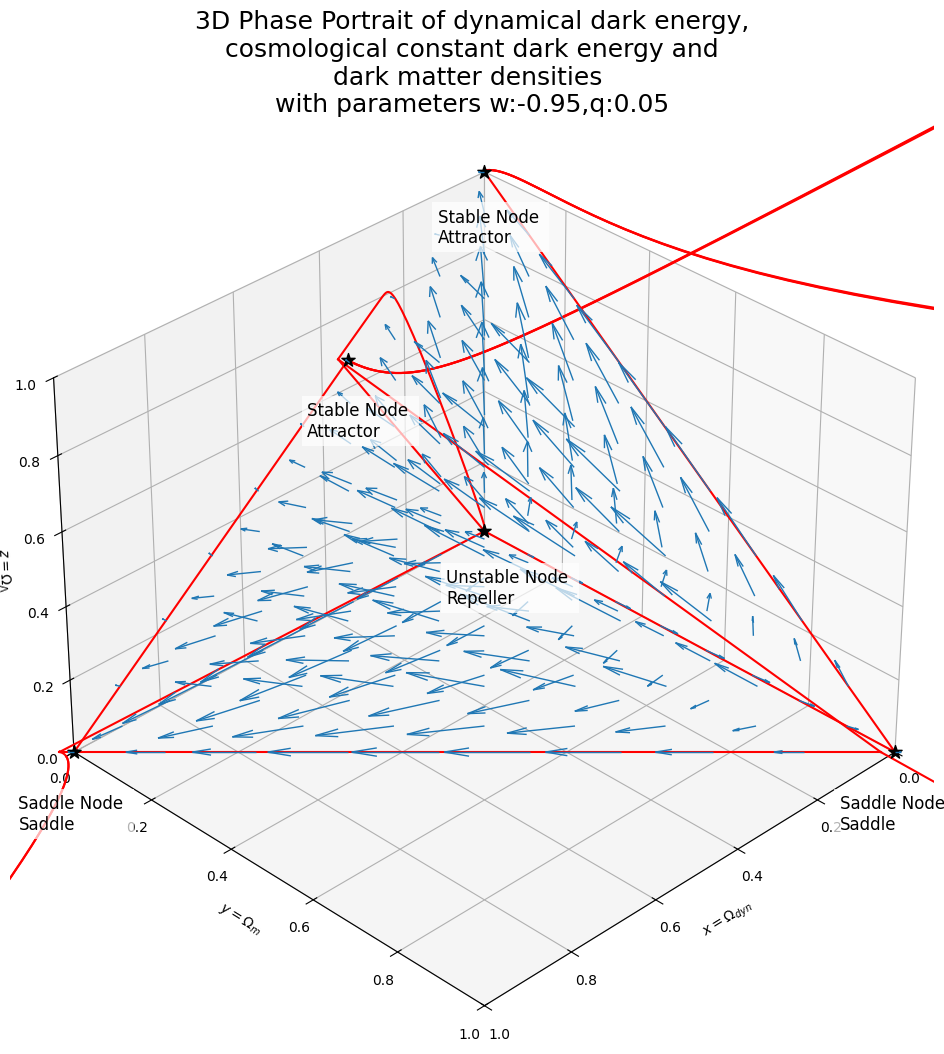

In [2]:
w, q = -0.95, 0.05


def system(t, vars):
    x, y, z = vars
    R = 1 - x - y - z

    dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
    dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
    dz = 3*z*x*(1+w) + 3*y*z + 4*z*R

    return [dx, dy, dz]


def integrate_separatrix(fp, v, direction, T=50, eps=1e-5,origin=None):

    fp = np.array(fp, dtype=float)
    v = np.array(v, dtype=float)

    # project onto simplex tangent space
    #v = v - np.mean(v)

    norm = np.linalg.norm(v) #normalise arrow lengths
    if norm == 0:
        return None
    v = v / norm

    if origin is not None:
        ref = fp - origin
        if np.dot(v, ref) < 0:
            v = -v


    P0 = fp + eps * v
    P0 = np.maximum(P0, 1e-12)

    t_span = [0, direction*T]
    sol = solve_ivp(system,t_span,P0,max_step=0.05,rtol=1e-8,atol=1e-8)

    return sol.y.T

def draw_lines_with_arrows(ax, traj, color='r', n_arrows=5, arrow_scale=0.08):

    traj = np.asarray(traj)
    if len(traj) < 2:
        return

    # plot the curved trajectory (optional but usually helpful)
    ax.plot(traj[:,0], traj[:,1], traj[:,2], color=color, lw=1.5)

    # cumulative arc-length parameterization
    seg = traj[1:] - traj[:-1]
    seg_len = np.linalg.norm(seg, axis=1)
    s = np.concatenate([[0], np.cumsum(seg_len)])

    if s[-1] == 0:
        return

    # normalized positions along curve
    t_vals = np.linspace(0.2, 0.8, n_arrows)

    for t in t_vals:
        dist = t * s[-1]

        # find segment
        i = np.searchsorted(s, dist) - 1
        i = np.clip(i, 0, len(traj) - 2)

        # local interpolation on curve
        local_t = (dist - s[i]) / (s[i+1] - s[i] + 1e-12)
        point = (1 - local_t) * traj[i] + local_t * traj[i+1]

        # tangent direction of trajectory (NOT endpoint direction)
        direction = traj[i+1] - traj[i]
        norm = np.linalg.norm(direction)
        if norm == 0:
            continue
        direction = direction / norm

        #ax.quiver(point[0], point[1], point[2],arrow_scale * direction[0],arrow_scale * direction[1],arrow_scale * direction[2],color=color,normalize=False,arrow_length_ratio=0.6)



def phase_plot_3D():

    fig = plt.figure(figsize=(12,12))
    ax = fig.add_subplot(111, projection='3d')
    xs = np.linspace(0, 1, 10)
    ys = np.linspace(0, 1, 10)
    zs = np.linspace(0, 1, 10)

    X, Y, Z = np.meshgrid(xs, ys, zs)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    W = np.zeros_like(Z)

    for i in range(10):
        for j in range(10):
            for k in range(10):

                xx, yy, zz = X[i,j,k], Y[i,j,k], Z[i,j,k]

                if xx + yy + zz > 1:
                    U[i,j,k] = np.nan
                    V[i,j,k] = np.nan
                    W[i,j,k] = np.nan
                    continue

                dx, dy, dz = system(0, [xx, yy, zz])

                U[i,j,k] = dx
                V[i,j,k] = dy
                W[i,j,k] = dz

    ax.quiver(X, Y, Z, U, V, W, length=0.15, linewidth=1.0)

    x, y, z = sp.symbols('x y z', real=True)
    R = 1 - x - y - z

    f = 3*(1+w)*(x**2 - x) + 3*x*y + q*(1 - 2*y - R) + 4*x*R
    g = 3*(y**2 - y) + 3*x*y*(1+w) - q*(1 - 2*y - R) + 4*y*R
    h = 3*z*x*(1+w) + 3*y*z + 4*z*R

    FP = []
    eigvec_list = []

    def add_fp(xv, yv, zv):

        pt = np.array([xv, yv, zv], dtype=float)

        if not any(np.allclose(pt, p, atol=1e-1) for p in FP):

            FP.append(pt)

            # numerical Jacobian
            eps = 1e-6
            J = np.zeros((3,3))

            base = np.array(system(0, pt))

            for i in range(3):
                shift = pt.copy()
                shift[i] += eps
                f1 = np.array(system(0, shift))

                shift[i] -= 2*eps
                f2 = np.array(system(0, shift))

                J[:, i] = (f1 - f2)/(2*eps)

            
            eigvals, eigvecs = np.linalg.eig(J)
            eigvec_list.append((eigvals, eigvecs))
            stability, point_type = classify_FP(eigvals)
            #ax.text(xv-0.05, yv+0.05, zv- 0.1, f"{point_type} \n"f'{stability}',fontsize=10)
            ax.text(xv+0.1, yv, zv- 0.15, f"{point_type} \n"f'{stability}',fontsize=12,bbox=dict(facecolor='white', edgecolor='none', alpha=0.7),zorder=1000)

            print(f"FP: ({xv:.3f}, {yv:.3f}, {zv:.3f})")
            print("Eigenvalues:", eigvals)
            print(f'type={point_type}')
            print(f'type={stability}\n')

    solutions = sp.solve([f, g, h], [x, y, z], dict=True)

    for sol in solutions:
        try:
            xv = float(sol[x])
            yv = float(sol[y])
            zv = float(sol[z])

            if xv >= 0 and yv >= 0 and zv >= 0 and xv+yv+zv <= 1+1e-6:
                add_fp(xv, yv, zv)

        except:
            pass

    #solving FP at boundaries
    # z = 0
    for sol in sp.solve([f.subs(z,0), g.subs(z,0)], [x,y], dict=True):
        try:
            add_fp(float(sol[x]), float(sol[y]), 0.0)
        except:
            pass

    # y = 0
    for sol in sp.solve([f.subs(y,0), h.subs(y,0)], [x,z], dict=True):
        try:
            add_fp(float(sol[x]), 0.0, float(sol[z]))
        except:
            pass

    # x = 0
    for sol in sp.solve([g.subs(x,0), h.subs(x,0)], [y,z], dict=True):
        try:
            add_fp(0.0, float(sol[y]), float(sol[z]))
        except:
            pass

    # vertices
    add_fp(0,0,0)
    add_fp(1,0,0)
    add_fp(0,1,0)
    add_fp(0,0,1)

    FP = np.array(FP)

    FP_manual = [[1,0,0],[0,1,0],[0,0,1],[0,0,0],[0.338,0,0.675]]
    for fp in FP_manual:
        ax.scatter(fp[0], fp[1], fp[2], color='k', s=100, marker='*')

    # separatrices
    for i, fp in enumerate(FP):

        eigvals, eigvecs = eigvec_list[i]

        for j in range(len(eigvals)):

            lam = eigvals[j]
            v = eigvecs[:, j]

            if np.real(lam) > 0:
                sol = integrate_separatrix(fp, v, +1,origin=fp)
                if sol is not None:
                    draw_lines_with_arrows(ax, sol, color='red')

            elif np.real(lam) < 0:
                sol = integrate_separatrix(fp, v, -1,origin=fp)
                if sol is not None:
                    draw_lines_with_arrows(ax, sol,  color='red')


    
    A = np.array([0, 1, 0])
    B = np.array([0, 0, 1])
    C = np.array([0, 0, 0])
    D =np.array([0.338, 0.000, 0.675])
    E = np.array([1, 0, 0])
    ax.plot([A[0], B[0]], [A[1], B[1]], [A[2], B[2]], color='red', linewidth=1.5)
    ax.plot([A[0], C[0]], [A[1], C[1]], [A[2], C[2]], color='red', linewidth=1.5)
    ax.plot([E[0], D[0]], [E[1], D[1]], [E[2], D[2]], color='red', linewidth=1.5)
    ax.set_xlabel(r'$x=\Omega_{dyn}$')
    ax.set_ylabel(r'$y=\Omega_{m}$')
    ax.set_zlabel(r'$z=\Omega_{\Lambda}$')

    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_zlim([0,1])

    ax.view_init(elev=33, azim=45)
    ax.set_title(f'3D Phase Portrait of dynamical dark energy,\n'f'cosmological constant dark energy and\n'f'dark matter densities \n'f'with parameters w:{w},q:{q}',fontsize=18)
    plt.show()

def classify_FP(eigvals, temp=1e-10):
    eigvals = np.array(eigvals, dtype=complex)
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)

    n_minus = np.sum(Real < -temp)
    n_pos = np.sum(Real > temp)
    n_zero = 3 - n_minus - n_pos
    has_imag = np.any(np.abs(Imag) > temp)

    if n_minus == 3:
        stability = 'Attractor'
    elif n_pos == 3:
        stability = 'Repeller'
    elif n_minus > 0 and n_pos > 0:
        stability = 'Saddle'
    elif n_zero > 0 and n_pos == 0:
        stability = 'non-hyperbolic (stable direction)'
    elif n_zero > 0 and n_minus == 0:
        stability = 'non-hyperbolic (unstable direction)'
    else:
        stability = 'intermediate'

    if has_imag:
        if stability == 'Attractor':
            point_type = 'Stable Spiral Attractor'
        elif stability == 'Repeller':
            point_type = 'Unstable Spiral Repeller'
        elif stability == 'Saddle':
            point_type = 'Spiral Saddle'
        else:
            point_type = 'Degenerate Spiral Focus/centre'
    else:
        if stability == 'Attractor':
            point_type = 'Stable Node'
        elif stability == 'Repeller':
            point_type = 'Unstable Node'
        elif stability == 'Saddle':
            point_type = 'Saddle Node'
        else:
            point_type = "Centre / Degenerate Node"

    return stability, point_type


phase_plot_3D()


### 3D plot of xyz but using $Q=qH\frac{\rho_X^2}{\rho_x+\rho_m} = q\frac{x^2+z^2+2xz}{1-R}$

solutions: -0.0178571246811410 1.01785712468114 0.0 

solutions: 0.0 0.0 0.0 

FP: (0.000, 0.000, 0.000)
Eigenvalues: [3.85000000e+00 3.03890064e+08 4.00000000e+00]
type=Unstable Node
type=Repeller

solutions: 0.0 0.0 1.00000000000000 

FP: (0.000, 0.000, 1.000)
Eigenvalues: [-4.   -0.15 -3.  ]
type=Stable Node
type=Attractor

solutions: 3.76293508936971e-7 -1.44873000940734e-6 0.0 

solutions: 1.00000000000000 0.0 0.0 

FP: (1.000, 0.000, 0.000)
Eigenvalues: [-3.85 -2.85  0.15]
type=Saddle Node
type=Saddle

solutions: 1200.00120000000 -60.0000600000000 -1139.00114000000 

FP: (-0.018, 1.018, 0.000)
Eigenvalues: [ 2.85       -0.94910719  3.05089281]
type=Saddle Node
type=Saddle

FP: (0.000, -1.304, 1.326)
Eigenvalues: [-0.57731195+22.7131635j -0.57731195-22.7131635j  0.00462391 +0.j       ]
type=Spiral Saddle
type=Saddle



/tmp/ipykernel_2161/884279743.py:18: ComplexWarning: Casting complex values to real discards the imaginary part
  v = np.array(v, dtype=float)


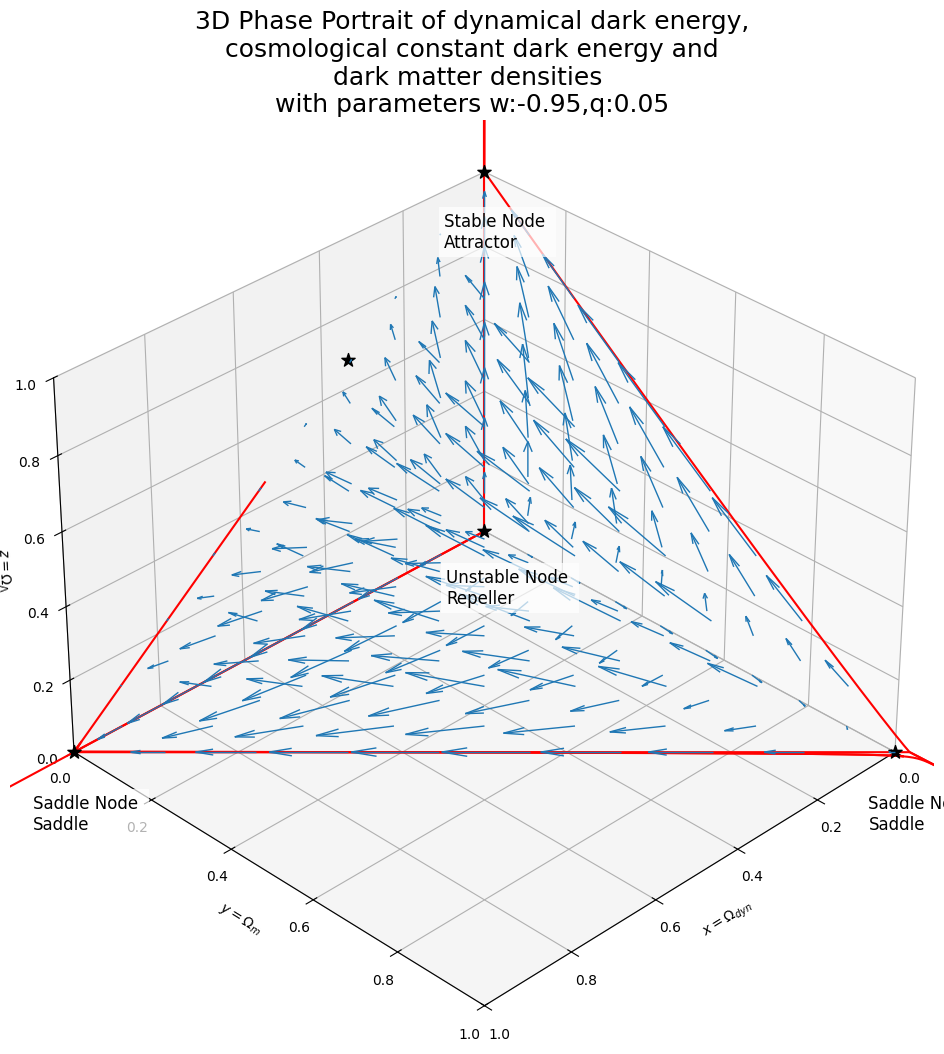

In [9]:
w, q = -0.95, 0.05


def system(t, vars):
    x, y, z = vars
    R = 1 - x - y - z

    dx = 3*(1+w)*(x**2 - x) + 3*x*y + q*(y**2)/(1-R+1e-6) + 4*x*R
    dy = 3*(y**2 - y) + 3*x*y*(1+w) - q*(y**2)/(1-R+1e-6) + 4*y*R
    dz = 3*z*x*(1+w) + 3*y*z + 4*z*R

    return [dx, dy, dz]


def integrate_separatrix(fp, v, direction, T=50, eps=1e-5,origin=None):

    fp = np.array(fp, dtype=float)
    v = np.array(v, dtype=float)

    # project onto simplex tangent space
    #v = v - np.mean(v)

    norm = np.linalg.norm(v) #normalise arrow lengths
    if norm == 0:
        return None
    v = v / norm

    if origin is not None:
        ref = fp - origin
        if np.dot(v, ref) < 0:
            v = -v


    P0 = fp + eps * v
    P0 = np.maximum(P0, 1e-12)

    t_span = [0, direction*T]
    sol = solve_ivp(system,t_span,P0,max_step=0.05,rtol=1e-8,atol=1e-8)

    return sol.y.T

def draw_lines_with_arrows(ax, traj, color='r', n_arrows=5, arrow_scale=0.08):

    traj = np.asarray(traj)
    if len(traj) < 2:
        return

    # plot the curved trajectory (optional but usually helpful)
    ax.plot(traj[:,0], traj[:,1], traj[:,2], color=color, lw=1.5)

    # cumulative arc-length parameterization
    seg = traj[1:] - traj[:-1]
    seg_len = np.linalg.norm(seg, axis=1)
    s = np.concatenate([[0], np.cumsum(seg_len)])

    if s[-1] == 0:
        return

    # normalized positions along curve
    t_vals = np.linspace(0.2, 0.8, n_arrows)

    for t in t_vals:
        dist = t * s[-1]

        # find segment
        i = np.searchsorted(s, dist) - 1
        i = np.clip(i, 0, len(traj) - 2)

        # local interpolation on curve
        local_t = (dist - s[i]) / (s[i+1] - s[i] + 1e-12)
        point = (1 - local_t) * traj[i] + local_t * traj[i+1]

        # tangent direction of trajectory (NOT endpoint direction)
        direction = traj[i+1] - traj[i]
        norm = np.linalg.norm(direction)
        if norm == 0:
            continue
        direction = direction / norm

        #ax.quiver(point[0], point[1], point[2],arrow_scale * direction[0],arrow_scale * direction[1],arrow_scale * direction[2],color=color,normalize=False,arrow_length_ratio=0.6)



def phase_plot_3D():

    fig = plt.figure(figsize=(12,12))
    ax = fig.add_subplot(111, projection='3d')
    xs = np.linspace(0, 1, 10)
    ys = np.linspace(0, 1, 10)
    zs = np.linspace(0, 1, 10)

    X, Y, Z = np.meshgrid(xs, ys, zs)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    W = np.zeros_like(Z)

    for i in range(10):
        for j in range(10):
            for k in range(10):

                xx, yy, zz = X[i,j,k], Y[i,j,k], Z[i,j,k]

                if xx + yy + zz > 1:
                    U[i,j,k] = np.nan
                    V[i,j,k] = np.nan
                    W[i,j,k] = np.nan
                    continue

                dx, dy, dz = system(0, [xx, yy, zz])

                U[i,j,k] = dx
                V[i,j,k] = dy
                W[i,j,k] = dz

    ax.quiver(X, Y, Z, U, V, W, length=0.15, linewidth=1.0)

    x, y, z = sp.symbols('x y z', real=True)
    R = 1 - x - y - z

    f = 3*(1+w)*(x**2 - x) + 3*x*y + q*(y**2)/(1-R+1e-6) + 4*x*R
    g = 3*(y**2 - y) + 3*x*y*(1+w) - q*(y**2)/(1-R+1e-6) + 4*y*R
    h = 3*z*x*(1+w) + 3*y*z + 4*z*R

    FP = []
    eigvec_list = []

    def add_fp(xv, yv, zv):

        pt = np.array([xv, yv, zv], dtype=float)

        if not any(np.allclose(pt, p, atol=1e-1) for p in FP):

            FP.append(pt)

            # numerical Jacobian
            eps = 1e-6
            J = np.zeros((3,3))

            base = np.array(system(0, pt))

            for i in range(3):
                shift = pt.copy()
                shift[i] += eps
                f1 = np.array(system(0, shift))

                shift[i] -= 2*eps
                f2 = np.array(system(0, shift))

                J[:, i] = (f1 - f2)/(2*eps)

            
            eigvals, eigvecs = np.linalg.eig(J)
            eigvec_list.append((eigvals, eigvecs))
            stability, point_type = classify_FP(eigvals)
            #ax.text(xv-0.05, yv+0.05, zv- 0.1, f"{point_type} \n"f'{stability}',fontsize=10)
            ax.text(xv+0.1, yv, zv- 0.15, f"{point_type} \n"f'{stability}',fontsize=12,bbox=dict(facecolor='white', edgecolor='none', alpha=0.7),zorder=1000)

            print(f"FP: ({xv:.3f}, {yv:.3f}, {zv:.3f})")
            print("Eigenvalues:", eigvals)
            print(f'type={point_type}')
            print(f'type={stability}\n')

    solutions = sp.solve([f, g, h], [x, y, z], dict=True)

    for sol in solutions:
        try:
            xv = float(sol[x])
            yv = float(sol[y])
            zv = float(sol[z])
            print('solutions:', sol[x], sol[y], sol[z],'\n')

            if xv >= 0 and yv >= 0 and zv >= 0 and xv+yv+zv <= 1+1e-6:
                add_fp(xv, yv, zv)

        except:
            pass

    #solving FP at boundaries
    # z = 0
    for sol in sp.solve([f.subs(z,0), g.subs(z,0)], [x,y], dict=True):
        try:
            add_fp(float(sol[x]), float(sol[y]), 0.0)
        except:
            pass

    # y = 0
    for sol in sp.solve([f.subs(y,0), h.subs(y,0)], [x,z], dict=True):
        try:
            add_fp(float(sol[x]), 0.0, float(sol[z]))
        except:
            pass

    # x = 0
    for sol in sp.solve([g.subs(x,0), h.subs(x,0)], [y,z], dict=True):
        try:
            add_fp(0.0, float(sol[y]), float(sol[z]))
        except:
            pass

    # vertices
    add_fp(0,0,0)
    add_fp(1,0,0)
    add_fp(0,1,0)
    add_fp(0,0,1)

    FP = np.array(FP)

    FP_manual = [[1,0,0],[0,1,0],[0,0,1],[0,0,0],[0.338,0,0.675]]
    for fp in FP_manual:
        ax.scatter(fp[0], fp[1], fp[2], color='k', s=100, marker='*')

    # separatrices
    for i, fp in enumerate(FP):

        eigvals, eigvecs = eigvec_list[i]

        for j in range(len(eigvals)):

            lam = eigvals[j]
            v = eigvecs[:, j]

            if np.real(lam) > 0:
                sol = integrate_separatrix(fp, v, +1,origin=fp)
                if sol is not None:
                    draw_lines_with_arrows(ax, sol, color='red')

            elif np.real(lam) < 0:
                sol = integrate_separatrix(fp, v, -1,origin=fp)
                if sol is not None:
                    draw_lines_with_arrows(ax, sol,  color='red')


    
    A = np.array([0, 1, 0])
    B = np.array([0, 0, 1])
    C = np.array([0, 0, 0])
    D =np.array([0.338, 0.000, 0.675])
    E = np.array([1, 0, 0])
    #ax.plot([A[0], B[0]], [A[1], B[1]], [A[2], B[2]], color='red', linewidth=1.5)
    #ax.plot([A[0], C[0]], [A[1], C[1]], [A[2], C[2]], color='red', linewidth=1.5)
    #ax.plot([E[0], D[0]], [E[1], D[1]], [E[2], D[2]], color='red', linewidth=1.5)
    ax.set_xlabel(r'$x=\Omega_{dyn}$')
    ax.set_ylabel(r'$y=\Omega_{m}$')
    ax.set_zlabel(r'$z=\Omega_{\Lambda}$')

    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_zlim([0,1])

    ax.view_init(elev=33, azim=45)
    ax.set_title(f'3D Phase Portrait of dynamical dark energy,\n'f'cosmological constant dark energy and\n'f'dark matter densities \n'f'with parameters w:{w},q:{q}',fontsize=18)
    plt.show()

def classify_FP(eigvals, temp=1e-10):
    eigvals = np.array(eigvals, dtype=complex)
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)

    n_minus = np.sum(Real < -temp)
    n_pos = np.sum(Real > temp)
    n_zero = 3 - n_minus - n_pos
    has_imag = np.any(np.abs(Imag) > temp)

    if n_minus == 3:
        stability = 'Attractor'
    elif n_pos == 3:
        stability = 'Repeller'
    elif n_minus > 0 and n_pos > 0:
        stability = 'Saddle'
    elif n_zero > 0 and n_pos == 0:
        stability = 'non-hyperbolic (stable direction)'
    elif n_zero > 0 and n_minus == 0:
        stability = 'non-hyperbolic (unstable direction)'
    else:
        stability = 'intermediate'

    if has_imag:
        if stability == 'Attractor':
            point_type = 'Stable Spiral Attractor'
        elif stability == 'Repeller':
            point_type = 'Unstable Spiral Repeller'
        elif stability == 'Saddle':
            point_type = 'Spiral Saddle'
        else:
            point_type = 'Degenerate Spiral Focus/centre'
    else:
        if stability == 'Attractor':
            point_type = 'Stable Node'
        elif stability == 'Repeller':
            point_type = 'Unstable Node'
        elif stability == 'Saddle':
            point_type = 'Saddle Node'
        else:
            point_type = "Centre / Degenerate Node"

    return stability, point_type


phase_plot_3D()


Detected fixed points: [array([ 0.344828, -0.017241]), array([ 1.017852, -0.017852]), array([0.017236, 0.982764])]
Fixed points (0.344828,-0.017241)
Eigen Values: [-0.0991218 -2.9508746]
Type=node
Stability=Attractor

Fixed points (0.017236,0.982764)
Eigen Values: [2.8517548 2.9508774]
Type=node
Stability=Repeller



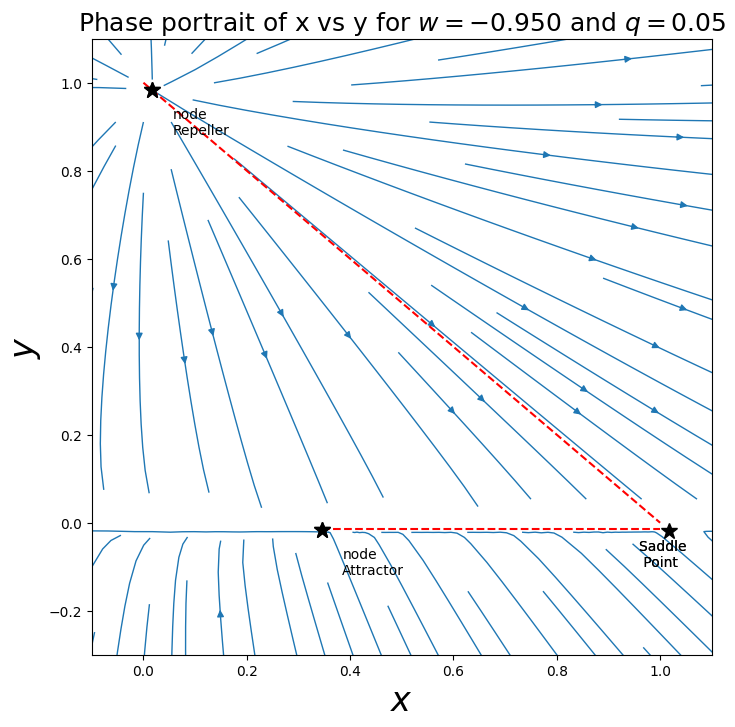

In [3]:
w,q =-0.95,0.05

def system(t,vars):
    x,y=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(1-2*y)#dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(1-2*y)#dynamic DM
    
    return [dx,dy]



simulationTime=np.linspace(-10,0,500)#  number of e folds of time, inflation lasted 50-60
# generate the state-space trajectory
ICs=[0.00001,0.99]

def traj(IC): # change to forward time -50,50 for expanding and 50,-50 reverse time for contracting
    sol = solve_ivp(system, t_span=(simulationTime[0],simulationTime[-1]), y0=ICs,t_eval=simulationTime, method='RK45', rtol=1e-6, atol=1e-6)
    return sol

def plot_traj(sol):
    x = sol.y[0]
    y = sol.y[1]

    #plt.plot(x,y ,color='r',linestyle='--',alpha = 0.7,label="Trajectory")
    x0,y0 = x[-2],y[-2]
    X_diff=x[-1] -x[-2]
    Y_diff=y[-1] -y[-2]
    plt.arrow(x0, y0, X_diff, Y_diff, head_width=0.03, head_length=0.05, length_includes_head=True, color='r',linestyle='--')


#plotting phase portrait 
def phase_plot():

  FP = find_fixed_points()
  

  
  print("Detected fixed points:",FP)


  # defining a grid of points at which we create/compute tangent arrows
  x0 = np.linspace(-1.5,1.5,500)
  x1 = np.linspace(-1.5,1.5,500)
  X0,X1 = np.meshgrid(x0,x1)
  dX0 = np.zeros(X0.shape)
  dX1 = np.zeros(X1.shape)

  for i in range(X0.shape[0]):
      for j in range(X0.shape[1]):
                if abs(X0[i,j]) >= 1.5 or abs(X1[i,j]) >= 1.5:
                  dX0[i,j] = 0
                  dX1[i,j] = 0
                else:
                  dx,dy = system(0,[X0[i,j], X1[i,j]])
                  dX0[i,j] = dx
                  dX1[i,j] = dy

  plt.figure(figsize=(8,8))
  plt.streamplot(X0, X1, dX0, dX1, density=1.9, linewidth=1)
  #plt.plot(x_vals, y_vals, 'r', lw=2, label='Trajectory')
  #plt.plot(x_vals[0], y_vals[0], 'ro', label='Initial condition')

    #   forcing the separatrices for w=-0.5 and q=-0.05, remove otherwise
    #1.54834,-1.50333
  a=np.linspace(0,1,100)
  b=[(-i)+1  for i in a]

  d=np.linspace(0.344828,1,100)
  c=np.zeros_like(d)
  plt.plot(a,b,'r--')
  plt.plot(d,c-0.015,'r--')




  initial_conditions = [(0.99, 0.01), (0.1, 0.99)]
  for dx0,dy0 in initial_conditions:
        sol = traj([dx0,dy0])
        plot_traj(sol)


  def classify_FP(eigvals,temp=1e-10):
    Real = np.real(eigvals)
    Imag = np.imag(eigvals)
    if np.all(Real<-temp):
      stability = 'Attractor'
    elif np.all(Real>temp):
      stability = 'Repeller'
    elif np.any(Real<-temp) and np.any(Real > temp):
      stability = 'saddle'
    elif np.all(np.abs(Real) < temp):
      stability = 'Centre'
    else:
      stability = 'NaN'
    if np.any(np.abs(Imag)>temp):
      point_type = 'Spiral'
    else:
      point_type = 'node'

    return stability,point_type

  for fp in FP:
    x_c, y_c = fp
    plt.plot(x_c, y_c, 'k*', markersize=12)
    delta = 1e-6
    # DO NOT skip the saddle at (1,0)
    if (abs(x_c) >= 1 or abs(y_c) >= 1) and not np.allclose([x_c, y_c], [1,0], atol=1e-3):
      
      stability = "saddle"
      point_type = "Boundary"

      starts = [
                [x_c-delta,y_c],
                [x_c,y_c-delta],
                [x_c-delta,y_c-delta],
                [x_c-delta,y_c+delta]
            ]

      for start in starts:

                  start = np.clip(start,-0.999,0.999)

                  sol = solve_ivp(system,(-10, 0),start,t_eval=simulationTime)
                  #plt.plot(sol.y[0], sol.y[1], 'r--')

      continue






    
    # creating a numerical jacobian because the sympy function doesnt work when functions blow up to infinities at +-1

    eps=1e-6
    fx1 = system(0,[x_c+eps,y_c])
    fx2 = system(0,[x_c-eps,y_c])

    fy1 = system(0,[x_c,y_c+eps])
    fy2 = system(0,[x_c,y_c-eps])

    J = np.array([
            [(fx1[0]-fx2[0])/(2*eps),(fy1[0]-fy2[0])/(2*eps)],
            [(fx1[1]-fx2[1])/(2*eps),(fy1[1]-fy2[1])/(2*eps)]
        ])

    eigvals,eigvecs = np.linalg.eig(J)

    stability,point_type = classify_FP(eigvals)




    print(f'Fixed points ({x_c:},{y_c:})')
    print('Eigen Values:',eigvals)
    print(f'Type={point_type}')
    print(f'Stability={stability}\n')
    plt.plot(x_c, y_c, 'k*', markersize=12,label='Fixed Points')
    plt.text(x_c+0.04, y_c-0.1, f"{point_type}\n{stability}", fontsize=10)
    plt.text(1-0.04, 0-0.1, f"Saddle \n Point", fontsize=10)
    
    #plt.plot(1,0,'k*', markersize=12,label='Saddle Point')
    #plt.text(1-0.04, 0-0.1, f"Saddle Point", fontsize=10)

  #plt.plot(1,0,'k*', markersize=12,label='Saddle Point')
  plt.xlabel(rf"$x$",fontsize=24)
  plt.ylabel(rf"$y$",fontsize=24)
  plt.title(rf"Phase portrait of x vs y for $w={w:.3f}$ and $q={q}$",fontsize=18)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.3,1.1)


  #plt.legend()
  
  plt.show()





def find_fixed_points():
    guesses = np.linspace(-1.5,1.5,40)
    FP = []
    for g1 in guesses:
        for g2 in guesses:
            sol = root(lambda v: system(0,[v[0],v[1]]), [g1,g2])
            if sol.success:
                x, y = sol.x

                if abs(x) <= 1.5 and abs(y) <= 1.5:
                    dx,dy = system(0,[x,y])

                    if abs(dx) < 1e-6 and abs(dy) < 1e-6:
                        pt = np.round([x,y],6)

                        if not any(np.allclose(pt,p,atol=1e-4) for p in FP):
                            FP.append(pt)

    return FP


phase_plot()

# https://aleksandarhaber.com/phase-portraits-of-state-space-models-and-differential-equations-in-python/, https://www.youtube.com/watch?v=DeeoiE22bZ8, method from https://iopscience.iop.org/article/10.1088/1475-7516/2018/01/018
